# **CMPM244 Final Project**
### **Group Name: Game 404 Not Found**
- Kyle Chang, kchan112@ucsc.edu
- Xinran Wang, xwang505@ucsc.edu
- Naharin Siddiqui Nawar, nanawar@ucsc.edu

### **Paper Topic**
> Story Quality as a Matter of Perception: Using Word Embeddings to Estimate Cognitive Interest (AIIDE-19)

### **README Instruction**

> Run code blocks `I. Functions` and `III. Modified Stories` to install requirements.\
Run `IV. Evaluation: BERT` to evaluate stories with a **BERT** model.\
Run `V. Evaluation: ModernBERT` to evaluate stories with a **ModernBERT** model.\
> \
> I. Functions\
> II. Raw Stories (M=0)\
> III. Modified Stories\
> IV. Evaluation: BERT\
> V. Evaluation: ModernBERT\
> \
> **Hyperparameters in Evaluation Code Blocks**
> - `story_set`: set to `all_story` to evaluate whole dataset; set to `single_story` to evaluate just one story.
> - `plot_mcs_yes`: bool, plot moving cosine similarity (mcs) graph
> - `print_outlier_yes`: bool, print the threshold value of the outlier selection algorithm
> - `calculating_mcs_with_skipped_tokens`: bool, whether to include the first sentence when calculating mcs; default is `True`, but if setting to `False`, the first value of the mcs graph will be assumed to be 1.

## I. Functions

In [ ]:
import torch, torch.nn.functional as F
import numpy as np
import re
import pandas as pd
import spacy
import matplotlib.pyplot as plt
import matplotlib.transforms as mtrans
import nltk
from datasets import load_dataset
from transformers import BertTokenizerFast, BertModel, AutoTokenizer, AutoModel
from tqdm.notebook import tqdm
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from scipy import stats

def sentence_split(story):
  """
  Split a story into sentences.

  Args:
    story (str): a story that has at least two sentences
  Returns:
    sents (list): a list of strings, each string is a sentence
  """
  story = story.strip()
  story = story.replace(",", "").replace("\"", "")  # remove comma and quotation marks
  pattern = r"[\n.!?]"                # punctuations to split by
  sents = re.split(pattern, story)
  sents = [s.strip() for s in sents if s.strip()]
  return sents

def rmv_name_and_stopwd(sentence, person_name):
  """
  Remove named-entities and stop words in a sentence.

  Args:
    sentence (str): a single sentence
    person_name (set): a set of names that's handcrafted to handle the names that can not be detected by BERT
  Returns:
    sentence_cleaned (str): a single sentence without named-entities and stop words
  """
  doc = nlp(sentence)
  cleaned_tokens = []
  for token in doc:
    if token.ent_type_ in ["DATE", "TIME"]:
      cleaned_tokens.append(token.text_with_ws)
      continue
    if token.ent_type_ == "PERSON":
      person_name.add(token.text)
      continue
    if token.text.endswith("'s") or token.text in person_name:
      continue
    cleaned_tokens.append(token.text_with_ws)

  text_wo_entities = "".join(cleaned_tokens).strip()
  words = word_tokenize(text_wo_entities)
  filtered_words = [word for word in words if word.lower() not in stop_words]
  sentence_cleaned = " ".join(filtered_words)

  return sentence_cleaned, person_name

def story_preprocess(story):
  """
  Run BERT on the story to retrieve word embedding vectors.

  Args:
    story (str): a story with multiple sentences
  Returns:
    tokens_cleaned (list): all tokens in the story with a format of sen#_(word), e.g. sen2_driving
    word_embeddings (list): embeddings of each word in tokens_cleaned
    each_word_sent_id (list): the sentence ID of each word in tokens_cleaned
    first_sentence_word_count (int): the number of words in the first sentence
  """
  story_split = sentence_split(story) # split the story into a list of sentences
  person_name = {"Beep", "Jordan"}  # put Beep in the set manually because spacy failed to recognize this name

  sentences = []  # processed story as a list of sentences
  for sentence in story_split:
    sentence_cleaned, person_name = rmv_name_and_stopwd(sentence, person_name)
    sentences.append(sentence_cleaned)

  # tokenization
  encoded_input = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True, add_special_tokens=True).to(DEVICE)
  input_ids = encoded_input['input_ids']
  attention_mask = encoded_input['attention_mask']

  # run BERT
  with torch.no_grad():
    output = model(**encoded_input)

  last_hidden_state = output.last_hidden_state   # last_hidden_state has a size = (batch_size, sequence_length, hidden_size)
                            # For a single sentence, batch_size will be 1. (I still get 1 with multiple sentence but I assume it wouldn't matter much)
                            # sequence_length corresponds to the number of tokens (including special tokens)
                            # hidden_size is the dimensionality of the embeddings (768 for bert-base-uncased, 1024 for bert-large-uncased).
  tokens_cleaned = []
  word_embeddings = []
  each_word_sent_id = []
  first_sentence_word_count = 0

  for i, sentence in enumerate(sentences):
    sentence_embeddings = last_hidden_state[i]
    tokens = tokenizer.convert_ids_to_tokens(input_ids[i])

    current_word_embedding = []
    for j in range(len(tokens)):

      if attention_mask[i][j] == 1 and input_ids[i][j] != 101 and input_ids[i][j] != 102 and tokens[j] != "," and tokens[j] != "." and tokens[j] != "!":# 101 is [CLS] and 102 is [SEP]
        if tokens[j].startswith('##'):
          tokens_cleaned[-1] = tokens_cleaned[-1] + tokens[j][2:]
          current_word_embedding.append(sentence_embeddings[j])
        elif tokens[j] == "n" or tokens[j] == "'" or tokens[j] == "t":
          tokens_cleaned[-1] = tokens_cleaned[-1] + tokens[j]
          current_word_embedding.append(sentence_embeddings[j])
        else:
          if current_word_embedding:
            word_embeddings.append(torch.mean(torch.stack(current_word_embedding), dim=0))
          current_word_embedding = [sentence_embeddings[j]]
          token_str = "sen" + str(i+1) + "_" + tokens[j]
          tokens_cleaned.append(token_str)
          each_word_sent_id.append(i)
          if i == 0:
            first_sentence_word_count += 1
    if current_word_embedding: # add the last word's embedding
      word_embeddings.append(torch.mean(torch.stack(current_word_embedding), dim=0))

  return tokens_cleaned, word_embeddings, each_word_sent_id, first_sentence_word_count


def story_preprocess_ModernBERT(story):
  story_split = sentence_split(story) # split the story (one string) to a list of sentences
  sentences = [] #sentence_split function is not correct


  person_name = {"Beep"}  # put Beep in the set manually because spacy failed to recognize this name
  # person_name = set()
  for sentence in story_split:
    sentence_processed, person_name = rmv_name_and_stopwd(sentence, person_name)
    sentences.append(sentence_processed)

  enc = tokenizer(
        sentences,
        return_tensors="pt",
        padding=True,
        truncation=True,
        add_special_tokens=True,
        return_offsets_mapping=True,
        max_length=min(tokenizer.model_max_length, 8192),
    )

  offsets = enc.pop("offset_mapping")
  enc.pop("token_type_ids", None)
  enc = {k: v.to(DEVICE) for k, v in enc.items()}

  # with torch.no_grad():
  #     out = model(**enc)

  # last_hidden_state = out.last_hidden_state

                            # sequence_length corresponds to the number of tokens (including special tokens)
                            # hidden_size is the dimensionality of the embeddings (768 for bert-base-uncased, 1024 for bert-large-uncased).
  with torch.no_grad():
    out = model(**enc, output_hidden_states=True)
    hs = torch.stack(out.hidden_states[-4:], dim=0).mean(dim=0)  # (batch, seq, hidden)
    last_hidden_state = hs



  tokens_cleaned = []
  word_embeddings_cleaned = []
  each_word_sent_id = []
  first_sentence_word_count = 0

  cls_id = tokenizer.cls_token_id
  sep_id = tokenizer.sep_token_id
  pad_id = tokenizer.pad_token_id

  for i, sent in enumerate(sentences):
        sent_embs = last_hidden_state[i]
        sent_offsets = offsets[i].tolist()

        # define "words" as non-whitespace spans in the processed sentence
        word_spans = [(m.start(), m.end(), m.group(0)) for m in re.finditer(r"\S+", sent)]
        if not word_spans:
            continue

        buckets = [[] for _ in word_spans]
        w = 0

        for j, (s, e) in enumerate(sent_offsets):
            if enc["attention_mask"][i, j].item() == 0:
                continue
            tid = int(enc["input_ids"][i, j].item())
            if tid in (cls_id, sep_id, pad_id) or e <= s:
                continue

            while w < len(word_spans) and s >= word_spans[w][1]:
                w += 1

            assigned = False
            if w < len(word_spans):
                ws, we, _ = word_spans[w]
                if s >= ws and e <= we:
                    buckets[w].append(sent_embs[j])
                    assigned = True

            if not assigned:
                for k, (ws, we, _) in enumerate(word_spans):
                    if max(s, ws) < min(e, we):  # any overlap
                        buckets[k].append(sent_embs[j])
                        break

        for (ws, we, word), embs in zip(word_spans, buckets):
            if not embs:
                continue
            tokens_cleaned.append(f"sen{i+1}_{word}")
            word_embeddings_cleaned.append(torch.stack(embs).mean(dim=0))
            each_word_sent_id.append(i)
            if i == 0:
                first_sentence_word_count += 1

  return tokens_cleaned, word_embeddings_cleaned, each_word_sent_id, first_sentence_word_count

def plot_mcs(moving_cosine_similarity, tokens_beheaded, story_index):
  """
  Plot moving cosine similarity graph.

  Args:
    moving_cosine_similarity (list): moving cosine similarity values
    tokens_beheaded (list): tokens starting from the first word of the second sentence
    idx (int): the index of the story
  """
  token_names_for_plot = []

  for idx, word in enumerate(tokens_beheaded):
    xlabel = word
    if xlabel not in token_names_for_plot:
      token_names_for_plot.append(xlabel)
    else:
      suffix = 2
      xlabel_temp = xlabel
      while xlabel_temp in token_names_for_plot:
        xlabel_temp = xlabel + str(suffix)
        suffix += 1
      token_names_for_plot.append(xlabel_temp)

  fig, ax = plt.subplots(figsize=(12, 3))
  ax.plot(token_names_for_plot, moving_cosine_similarity)
  xtick_labels = ax.get_xticklabels()
  trans = mtrans.Affine2D().translate(8, 2)
  for t in xtick_labels:
    t.set_transform(t.get_transform() + trans)
  plt.xticks(rotation=90, ha='right')
  plt.title(f'Moving Cosine Similarity for Story ID {story_index}')
  plt.grid(True)
  plt.show()



def mcs(word_embeddings, first_sentence_word_count):
  """
  Calculate moving cosine similarity with the word embedding vectors obtained from BERT.

  Args:
    word_embeddings (list): word embedding vectors
    first_sentence_word_count (int): the number of words in the first sentence
  Returns:
    moving_cosine_similarity (list): moving cosine similarity values for each word starting from the first word of the second sentence in the story
  """
  moving_cosine_similarity = []

  for i, word_vec in enumerate(word_embeddings):

    if i < first_sentence_word_count:
      continue

    if calculating_mcs_with_skipped_tokens:
      all_previous_vectors_mean = torch.mean(torch.stack(word_embeddings[:i]), dim=0)
    else:
      if i == first_sentence_word_count:
        all_previous_vectors_mean = word_vec
        print('Warning! First Moving Cosine Similarity is assumed to be 1.')
      else:
        all_previous_vectors_mean = torch.mean(torch.stack(word_embeddings[first_sentence_word_count:i]), dim=0)

    cosine_similarity = F.cosine_similarity(all_previous_vectors_mean, word_vec, dim=0)
    moving_cosine_similarity.append(cosine_similarity.item())

  return moving_cosine_similarity


def select_outliers(moving_cosine_similarity, mcs_sent_ids, story_index):
  """
  Outlier selection algorithm that gradually reduce threshold
  until (and if) there are exact two sentences that have the lowest mcs values.

  Args:
    moving_cosine_similarity (list): moving cosine similarity values starting from the first word of the second sentence in the story
    mcs_sent_ids (list): the sentence ID of each word excluding the first sentence of the story
  Returns:
    outlier_positions (list): position indices of outlying words; indices start from the first word of the second sentence
    If the outlier condition can not be met, return None.
  """
  mcs = np.asarray(moving_cosine_similarity, dtype=float)
  Q1 = np.percentile(mcs, 25)
  Q3 = np.percentile(mcs, 75)
  IQR = Q3 - Q1

  i = 0
  while True:
    thr = Q1 - IQR*i*0.6
    outlier_positions = np.where(mcs <= thr)[0].tolist()
    sents = sorted({mcs_sent_ids[j]+1 for j in outlier_positions})
    if print_outlier_yes:
      print(f'Story ID {story_index}, sentence number of outlier at threshold {thr:.4f}: {sents}')
    if len(sents) == 2:
      print('\n\n\n')
      return outlier_positions
    elif len(sents) < 2:
      break
    i += 1
  print('\n\n\n')
  return None


def compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id, story_index):
  """
  Compute M value for the story.

  Args:
    word_embeddings (list): word embedding vectors
    moving_cosine_similarity (list): moving cosine similarity values for each word starting from the first word of the second sentence
    first_sentence_word_count (int): the number of words in the first sentence
    each_word_sent_id (list): the sentence ID of every word in the story (including first sentence)
  Returns:
    M = 0 if outlier condition is not satisfied, else, calculate M with A and B as below.

    A = 1 - cos(mean(all), mean(outliers))
    B = avg_i cos(o_i, mean(outliers wo/ {i}))
    M = (A + |B|)/3

  """
  mcs_sent_ids = each_word_sent_id[first_sentence_word_count:]
  unique_after_first = sorted(set(mcs_sent_ids))

  if len(unique_after_first) < 2:
    print("M = 0 because the story is too short (less than two sentences)")
    return 0.0, 0.0, 0.0

  outlier_positions = select_outliers(moving_cosine_similarity, mcs_sent_ids, story_index)

  if not outlier_positions:
    return 0.0, 0.0, 0.0  # per paper, M=0 if we can't find exactly two sentences

  outlier_word_idxs = [first_sentence_word_count + j for j in outlier_positions]  # map back to original word indices
  outlier_vectors = [word_embeddings[i] for i in outlier_word_idxs]

  # A = 1 - cos(mean(all_words), mean(outlier_words))
  all_mean = torch.stack(word_embeddings, dim=0).mean(dim=0)
  out_mean = torch.stack(outlier_vectors, dim=0).mean(dim=0)
  A = 1.0 - F.cosine_similarity(all_mean, out_mean, dim=0).item()

  # B = avg over i in outlier set of cos(outlier_i, mean(outlier \ {i}))
  out = torch.stack(outlier_vectors, dim=0)
  sims = [] # a list of cosine similarity values
  for i in range(len(outlier_vectors)):
    others = torch.cat((out[:i], out[i+1:]), dim=0).mean(dim=0)
    sims.append(F.cosine_similarity(out[i], others, dim=0).item())
  B = float(np.mean(sims))

  M = (A + abs(B)) / 3.0

  return float(M), float(A), float(B)


def build_table(results):
  """Build table of M"""
  df = pd.DataFrame(results, columns=["M","A","B","Note"])
  df_nonzero = df[df["M"] > 0]
  num_total = len(df)
  num_nonzero = (df["M"] > 0).sum()
  ratio = (num_nonzero / num_total) if num_total else float('nan')
  print(f"\nStories processed: {num_total}")
  print(f"Stories with M ≠ 0: {num_nonzero} ({ratio:.2%})")
  # print("\nM Summary:")
  # print(df["M"].describe())
  display(df[["M","A","B","Note"]])


def single_story_run(story, result, tag, idx):
  tokens, word_embeddings, sent_ids, first_sentence_word_count = story_preprocess(story)
  moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count)
  if plot_mcs_yes:
    plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], idx)
  M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, sent_ids, idx)
  result.append((M, A, B, tag))
  return M, A, B, result

def single_story_run_ModernBERT(story, result, tag, idx):
  tokens, word_embeddings, sent_ids, first_sentence_word_count = story_preprocess_ModernBERT(story)
  moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count)
  if plot_mcs_yes:
    plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], idx)
  M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, sent_ids, idx)
  result.append((M, A, B, tag))
  return M, A, B, result

def story_set_run(story_set):
  result = []
  for idx, story in enumerate(story_set):

    # single story evaluation
    if len(story_set) == 1:
      tag = "-"

    # all story evaluation
    elif idx <= 8:
      tag = "restaurant"
    elif idx <= 17:
      tag = "work routine"
    elif idx <= 26:
      tag = "airport"
    else:
      tag = "bank"

    M, A, B, result = single_story_run(story, result, tag, idx)
  build_table(result)
  return result

def story_set_run_ModernBERT(story_set):
  result = []
  for idx, story in enumerate(story_set):

    # single story evaluation
    if len(story_set) == 1:
      tag = "-"

    # all story evaluation
    elif idx <= 8:
      tag = "restaurant"
    elif idx <= 17:
      tag = "work routine"
    elif idx <= 26:
      tag = "airport"
    else:
      tag = "bank"

    M, A, B, result = single_story_run_ModernBERT(story, result, tag, idx)
  build_table(result)
  return result


In [ ]:
## SpaCy, named-entities remover
nlp = spacy.load("en_core_web_sm")
# !python -m spacy download en_core_web_lg
# nlp = spacy.load('en_core_web_lg')

# nltk, stop words remover
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


## II. Raw Stories (M = 0)

In [ ]:
## Raw stories ready for hint/twist insertion
"""
Restaurant Story M=0.0

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.

--------------------------------------------------------------------------------
Work Routine Story M=0.0

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.

--------------------------------------------------------------------------------

Airport Story M=0.0

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
--------------------------------------------------------------------------------

Bank Story M=0.0

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.

"""

## III. Modified Stories

In [ ]:
######################
## 1. RESTAURANT ##
######################
restaurant_kyle = [
"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
The waiter was nervous when he put a mini GPS tracker into their food.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
Through the GPS tracker, the waiter lurked into their home and killed them in their sleep.""",

"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
They did not notice the shattered glasses on the floor.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
On the road, they had a flat tire because one of the tire was pierced by the shattered glass.""",

"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
The waiter secretly added an unknown powder to their food without being noticed.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
On their way home, the powder began to take effect, swapping their souls."""
]

restaurant_cindy = [
"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Judy noticed a small scratch on the car door that hadn’t been there earlier.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
When they arrived home, their garage door was already open even though they had closed it that morning.""",

"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
A faint smell of burning rubber drifted into the restaurant every time the door opened.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
Halfway home, smoke suddenly rose from under the hood as their car broke down in the same spot where Sam had parked earlier.""",

"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Judy thought she saw someone duck behind their parked car as they walked toward the entrance.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
When they got home, muddy footprints led from their driveway to their back door."""
]

restaurant_naharin = [
"""Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
They noticed that the waiter was sweating profusely, constantly glancing around the dining room.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
As they stepped outside, they heard the manager shout, Somebody call security, that man wasn't our waiter!""",

"""Sam and Judy went out for dinner at their favorite restaurant.
On their way out the door, Sam noticed their porch light flicker twice, though the power in the house was fine.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
As they stood to leave the restaurant, Judy realized her phone had recorded a call she never made from a number matching their home address.
They paid their tab, left a tip for the waiter, and drove back home.""",

"""Sam and Judy went out for dinner at their favorite restaurant.
Judy had grown up never knowing who her biological father was.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
Later that night, Judy received a text from an unknown number saying it was the waiter from the restaurant and he was her father."""
]

################################
## 2. WORK ROUTINE STORY ##
################################
work_routine_kyle = [
"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A man passed by Ethan and reccklessly bumped his shoulder.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Only until then, Ethan realized his watch was stolen by the man who bumped him.""",

"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
She did not watch the road and was tripped by a huge pothole, causing her knee to bleed.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Tina's wound was infected by an alien virus and she turned into a intimidating zombie.""",

"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A little puppy followed them along without being noticed.
They arrived at the company and started their usual routine.
When they got off work, they saw the puppy waiting patiently at the company entrance.
They decided to take in the puppy as their pet, and they lived happily ever after."""
]

work_routine_cindy = [
"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A delivery truck slowly rolled beside them for several blocks without ever passing.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Minutes after they entered the building, the same delivery truck pulled up and a man stepped out asking specifically for Ethan.""",

"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A strange buzzing announcement echoed faintly from a nearby street speaker, but neither of them could understand the words.
They arrived at the company and started their usual routine.
Seconds after they walked inside, all phones in the building lit up with an emergency alert instructing everyone to evacuate immediately.""",

"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A bus driver stared at Ethan through the window as it passed, as if recognizing him.
They arrived at the company and started their usual routine.
Hours later, Ethan saw the same bus driver waiting at the lobby desk asking for him by name."""
]

work_routine_naharin = [
"""Ethan and Tina began their morning commute together along the sidewalk.
Tina noticed a man in a company jacket quickly take a photo of her.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
At the company entrance, the same man approached Tina and asked if she wanted to model for his agency.
They arrived at the company and started their usual routine.""",

"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A man walking his dog smiled at Ethan and said, “See you inside,” even though Ethan didn’t know him.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Only then did Ethan realize the man with the dog was his new boss.""",

"""Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster, watching the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A delivery truck drove past and a small box tumbled out onto the sidewalk at Ethan’s feet, so he picked it up.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Only then did Ethan notice the box had his name on it and the company logo."""
]

##########################
## 3. AIRPORT STORY ##
##########################
airport_kyle = [
"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
A weird creature lurked into the seat pocket quietly.
The aisle remains clear near Jordan's seat.
After Jordan fell asleep, a poisonous snake came out from the seat pocket and bit Jordan in the leg, causing Jordan to die in agonizingly pain.""",

"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A tiny but deadly air cannon was hidden inside his backpack.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
Jordan used the air cannon to hijack the plane and made everyone give in their airplane meals.""",

"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
He did not notice a man quietly approaching him.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
The man sneaked up to Jordan, tagging him as the next tagger in the tagging game."""
]

airport_cindy = [
"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
The boarding sign flickered once and briefly showed the wrong destination before switching back.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
As the doors closed, Jordan heard the pilot announce a destination he had never booked.""",

"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
Jordan noticed the windows reflected only his seat row, not the rest of the cabin.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
When Jordan looked back, every other seat on the plane was suddenly filled despite no one boarding with him.""",

"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
Jordan noticed that the safety card listed a different airline than the one printed on his ticket.
The aisle remains clear near Jordan's seat.
Once the door closed, a prerecorded message welcomed passengers aboard a flight Jordan had never heard of."""
]

airport_naharin = [
"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
A folded note was tucked behind the safety card, addressed to Jordan by name.
The aisle remains clear near Jordan's seat.
When Jordan opened the note, it warned him not to buckle his seatbelt because the seat was not really bolted to the floor.""",

"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number and a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
His backpack suddenly feels much heavier than it did earlier.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
Jordan opens his backpack to check, and his stomach drops when he finds a large knife inside.""",

"""Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number and a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
He notices an old woman sitting a few rows ahead, perfectly still.
The seat pocket in front of Jordan contains the standard safety card.
When he looks up again, the old woman is gone, and Jordan isn’t sure if he imagined her.
The aisle remains clear near Jordan's seat."""
]

#######################
## 4. BANK STORY ##
#######################

bank_kyle = [
"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They look anxious and sweaty because they are planning something evil.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, they took out guns and cruelly shot everyone dead.
They took all the money and escaped the building.""",

"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
Behind them, a smelly, bald man carrying a rifle bumped open the door and entered the bank.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the man killed all the people in line because they are in fact the real robbers.""",

"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They did not notice that the bank was closing soon.
They watched the people ahead of them shuffle forward in small increments.
When it was their turn, the staff told them they were closed for the day, making them desperately angry."""
]

bank_cindy = [
"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
The security guard kept nervously adjusting his earpiece and glancing at the entrance.
They watched the people ahead of them shuffle forward in small increments.
Moments later, the bank doors locked automatically and an announcement instructed everyone to remain still for an unspecified investigation.""",

"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
A man near the entrance kept adjusting his backpack straps and whispering to two others who hadn't joined the line.
Moments later, the three men locked the doors and announced a robbery just as Anna's group reached the front of the line.""",

"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
A man near the wall kept tapping his foot rapidly while another lingered by the exit pretending to scroll his phone.
As the next customer stepped forward, both men suddenly pulled masks over their faces and announced the start of a robbery."""
]

bank_naharin = [
"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
A man a few places ahead of them kept fidgeting and looking around the lobby.
They watched the people ahead of them shuffle forward in small increments.
Without warning, the man pulled out a gun and fired.""",

"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
A child in the line looked pale and was sweating heavily.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the child swayed and fainted.""",

"""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
A dog was in the line and looked at Anna, growling.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the dog jumped and attacked Anna."""
]

# Story ID Reference
# 0~8, Restaurant story
# 9~17, work routine story
# 18~26, airport story
# 27~35, bank story

## IV. Evaluation: BERT

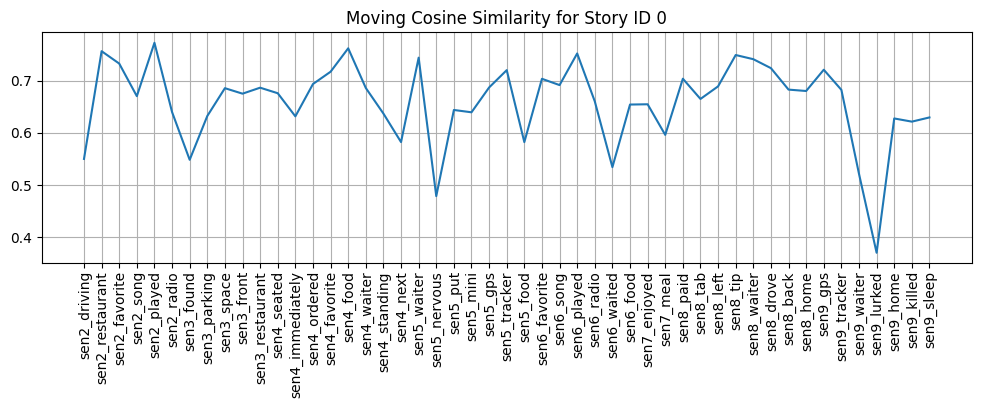

Story ID 0, sentence number of outlier at threshold 0.6318: [2, 3, 4, 5, 6, 7, 9]
Story ID 0, sentence number of outlier at threshold 0.5885: [2, 3, 4, 5, 6, 9]
Story ID 0, sentence number of outlier at threshold 0.5452: [5, 6, 9]
Story ID 0, sentence number of outlier at threshold 0.5019: [5, 9]






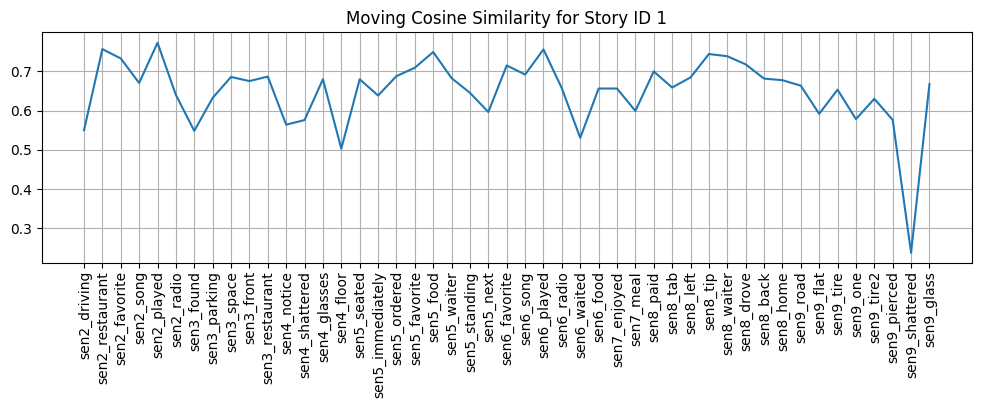

Story ID 1, sentence number of outlier at threshold 0.6147: [2, 3, 4, 5, 6, 7, 9]
Story ID 1, sentence number of outlier at threshold 0.5695: [2, 3, 4, 6, 9]
Story ID 1, sentence number of outlier at threshold 0.5244: [4, 9]






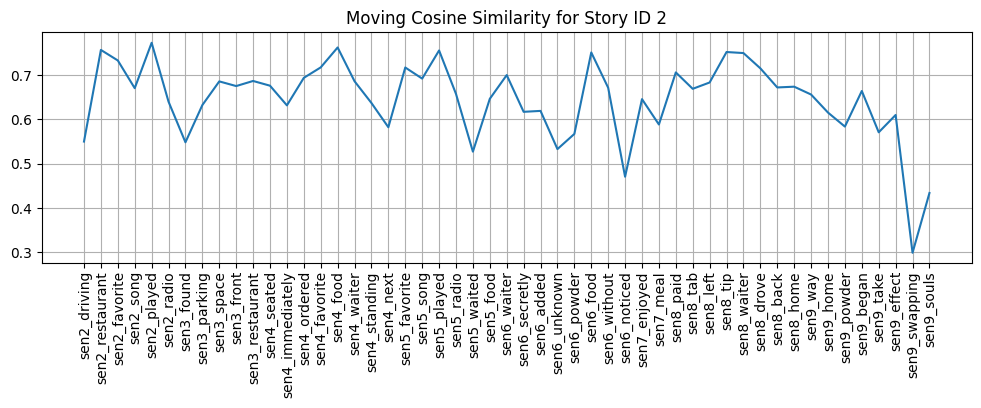

Story ID 2, sentence number of outlier at threshold 0.6128: [2, 3, 4, 5, 6, 7, 9]
Story ID 2, sentence number of outlier at threshold 0.5623: [2, 3, 5, 6, 9]
Story ID 2, sentence number of outlier at threshold 0.5118: [6, 9]






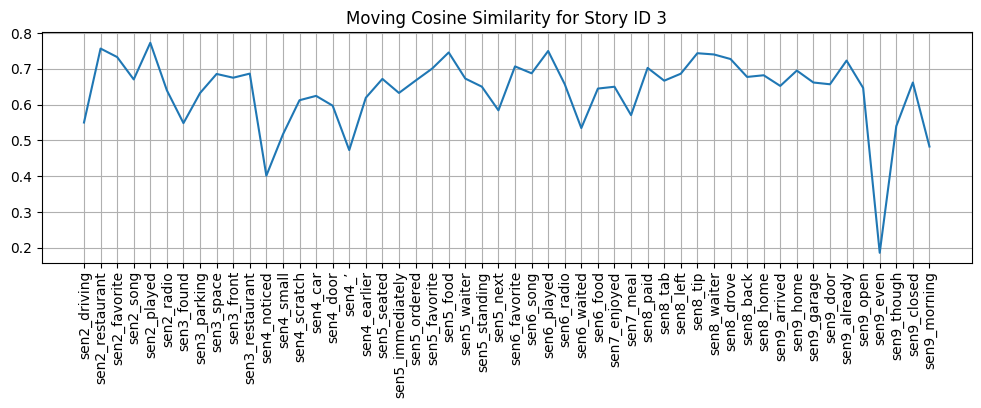

Story ID 3, sentence number of outlier at threshold 0.6176: [2, 3, 4, 5, 6, 7, 9]
Story ID 3, sentence number of outlier at threshold 0.5744: [2, 3, 4, 6, 7, 9]
Story ID 3, sentence number of outlier at threshold 0.5313: [4, 9]






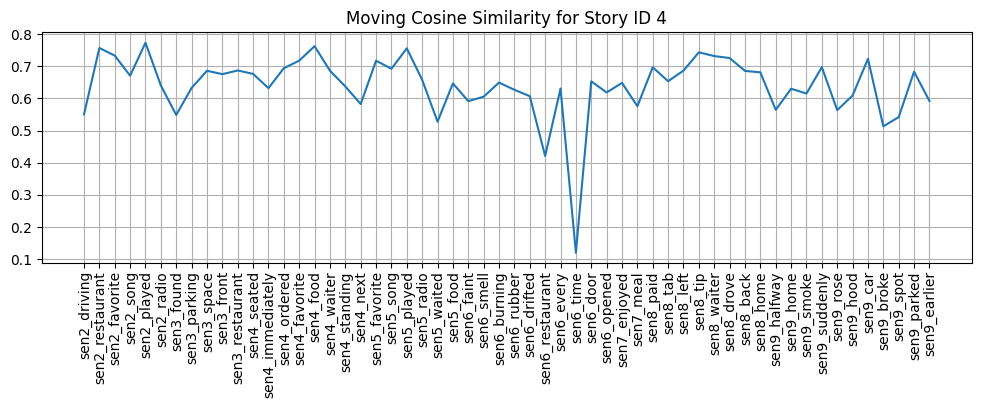

Story ID 4, sentence number of outlier at threshold 0.6064: [2, 3, 4, 5, 6, 7, 9]
Story ID 4, sentence number of outlier at threshold 0.5546: [2, 3, 5, 6, 9]
Story ID 4, sentence number of outlier at threshold 0.5029: [6]






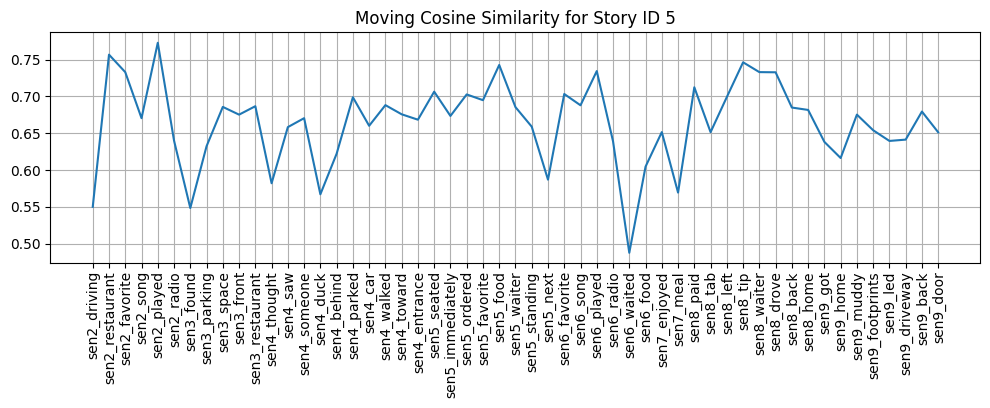

Story ID 5, sentence number of outlier at threshold 0.6396: [2, 3, 4, 5, 6, 7, 9]
Story ID 5, sentence number of outlier at threshold 0.6040: [2, 3, 4, 5, 6, 7]
Story ID 5, sentence number of outlier at threshold 0.5684: [2, 3, 4, 6]
Story ID 5, sentence number of outlier at threshold 0.5328: [6]






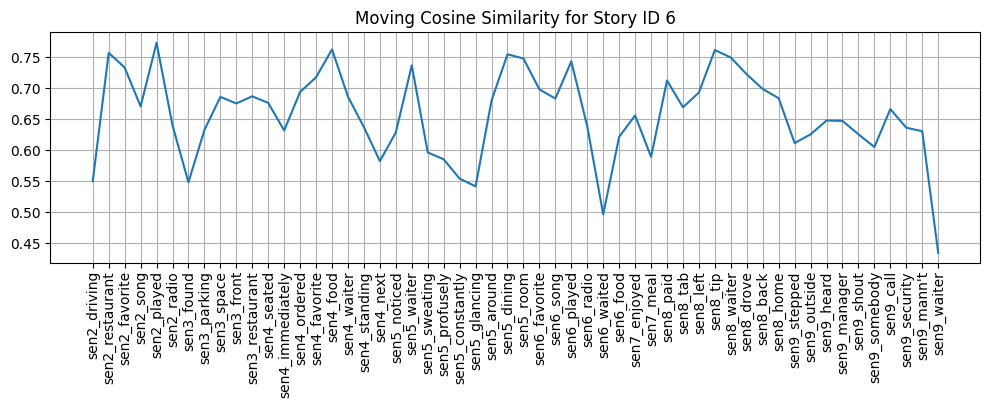

Story ID 6, sentence number of outlier at threshold 0.6256: [2, 3, 4, 5, 6, 7, 9]
Story ID 6, sentence number of outlier at threshold 0.5819: [2, 3, 5, 6, 9]
Story ID 6, sentence number of outlier at threshold 0.5382: [6, 9]






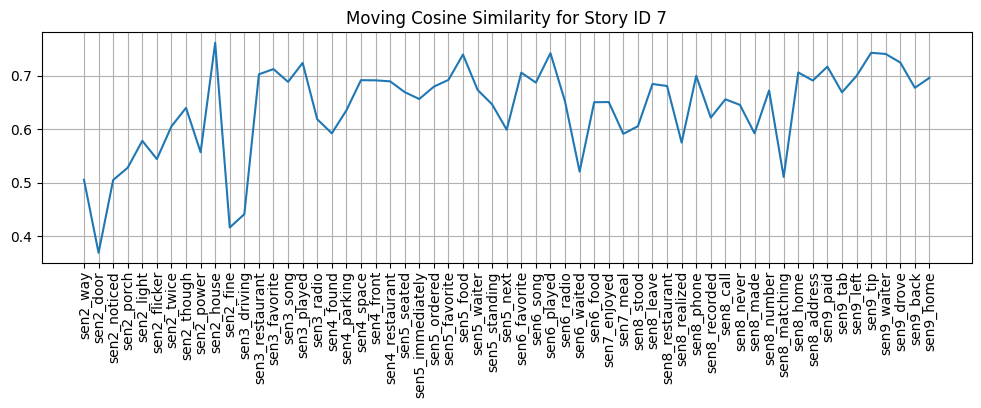

Story ID 7, sentence number of outlier at threshold 0.5958: [2, 3, 4, 6, 7, 8]
Story ID 7, sentence number of outlier at threshold 0.5366: [2, 3, 6, 8]
Story ID 7, sentence number of outlier at threshold 0.4775: [2, 3]






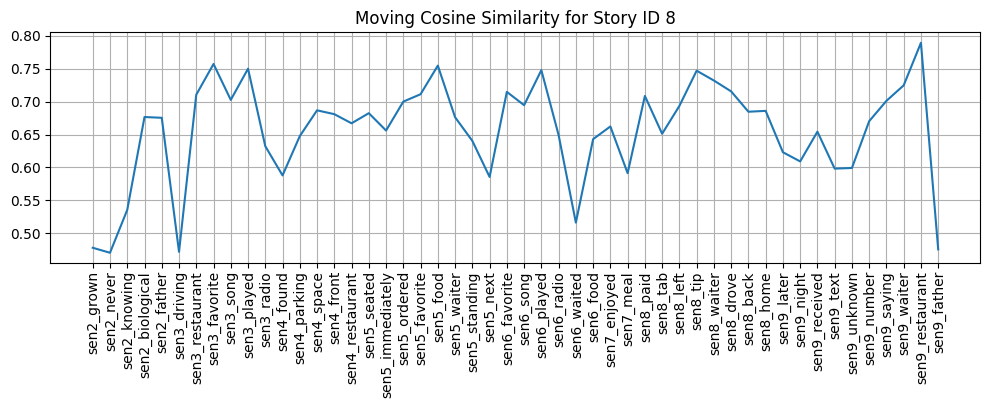

Story ID 8, sentence number of outlier at threshold 0.6254: [2, 3, 4, 5, 6, 7, 9]
Story ID 8, sentence number of outlier at threshold 0.5764: [2, 3, 6, 9]
Story ID 8, sentence number of outlier at threshold 0.5273: [2, 3, 6, 9]
Story ID 8, sentence number of outlier at threshold 0.4782: [2, 3, 9]
Story ID 8, sentence number of outlier at threshold 0.4292: []






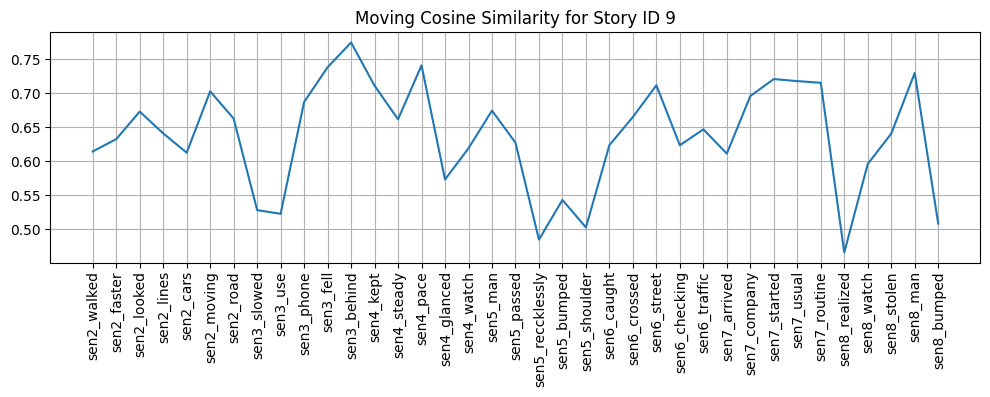

Story ID 9, sentence number of outlier at threshold 0.6108: [3, 4, 5, 7, 8]
Story ID 9, sentence number of outlier at threshold 0.5558: [3, 5, 8]
Story ID 9, sentence number of outlier at threshold 0.5009: [5, 8]






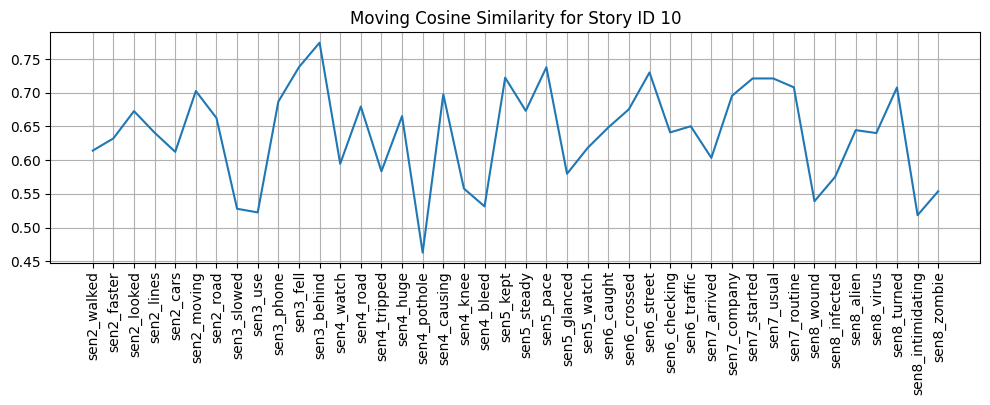

Story ID 10, sentence number of outlier at threshold 0.5861: [3, 4, 5, 8]
Story ID 10, sentence number of outlier at threshold 0.5196: [4, 8]






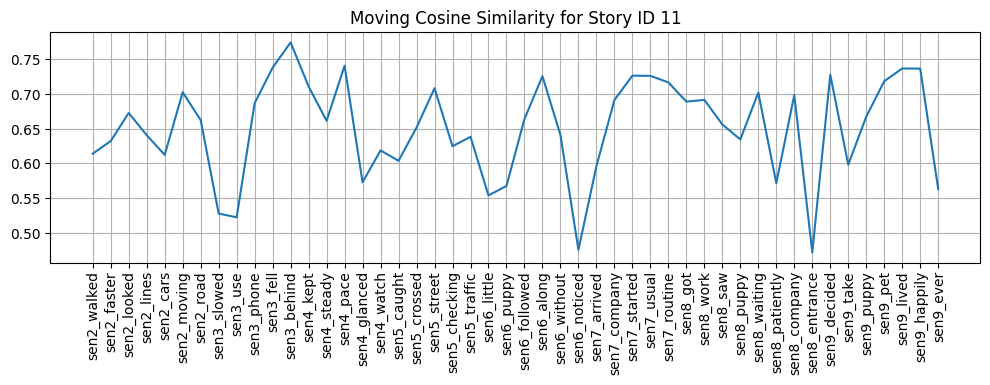

Story ID 11, sentence number of outlier at threshold 0.6100: [3, 4, 5, 6, 7, 8, 9]
Story ID 11, sentence number of outlier at threshold 0.5508: [3, 6, 8]
Story ID 11, sentence number of outlier at threshold 0.4916: [6, 8]






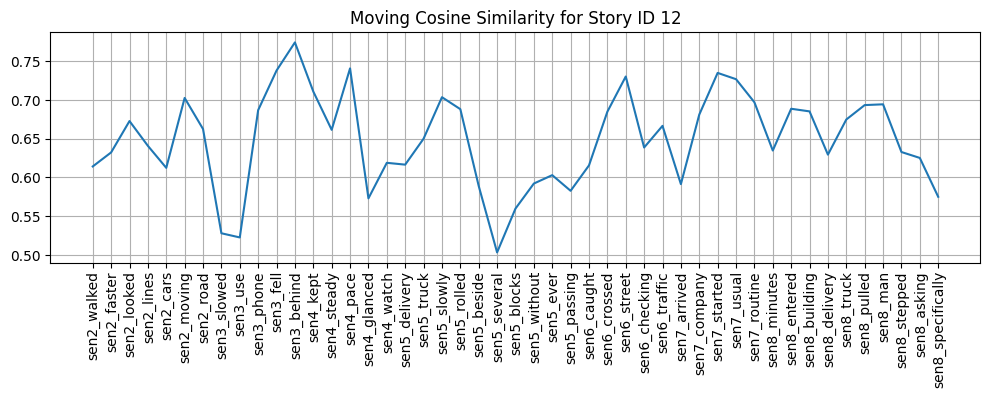

Story ID 12, sentence number of outlier at threshold 0.6131: [2, 3, 4, 5, 7, 8]
Story ID 12, sentence number of outlier at threshold 0.5664: [3, 5]






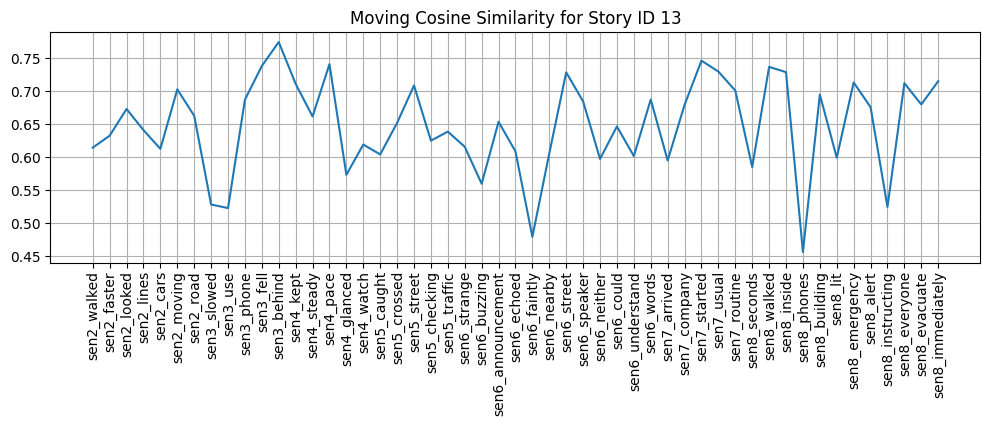

Story ID 13, sentence number of outlier at threshold 0.6045: [3, 4, 5, 6, 7, 8]
Story ID 13, sentence number of outlier at threshold 0.5440: [3, 6, 8]
Story ID 13, sentence number of outlier at threshold 0.4836: [6, 8]






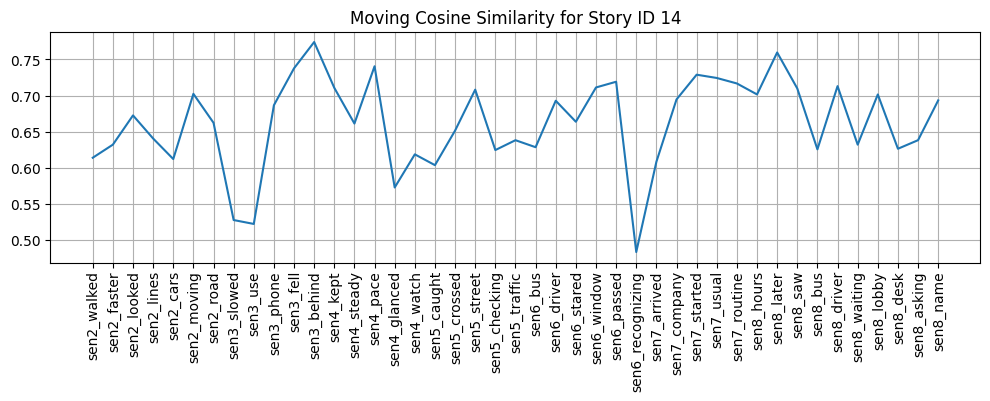

Story ID 14, sentence number of outlier at threshold 0.6260: [2, 3, 4, 5, 6, 7, 8]
Story ID 14, sentence number of outlier at threshold 0.5754: [3, 4, 6]
Story ID 14, sentence number of outlier at threshold 0.5249: [3, 6]






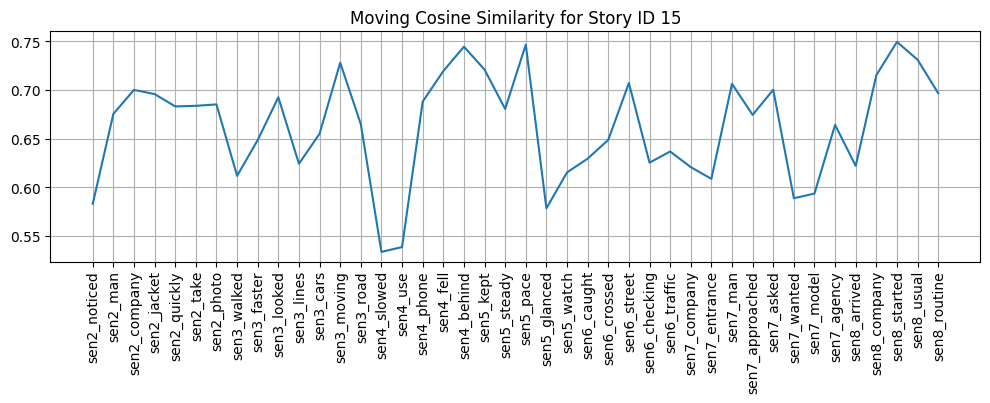

Story ID 15, sentence number of outlier at threshold 0.6224: [2, 3, 4, 5, 7, 8]
Story ID 15, sentence number of outlier at threshold 0.5757: [4]






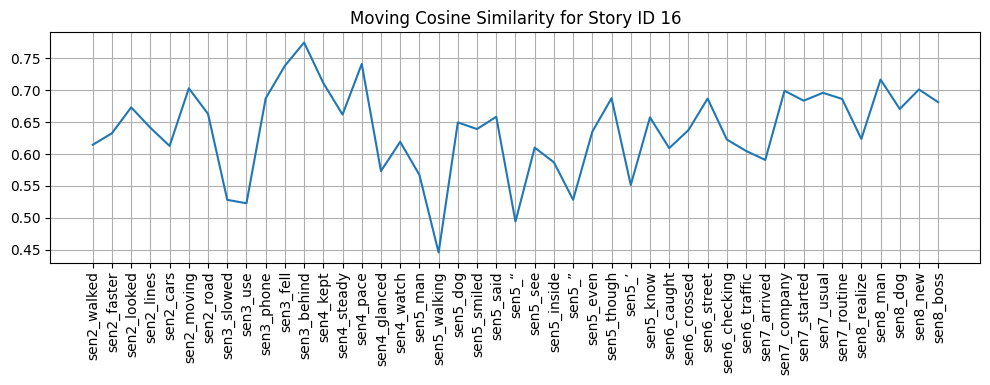

Story ID 16, sentence number of outlier at threshold 0.6087: [3, 4, 5, 6, 7]
Story ID 16, sentence number of outlier at threshold 0.5621: [3, 5]






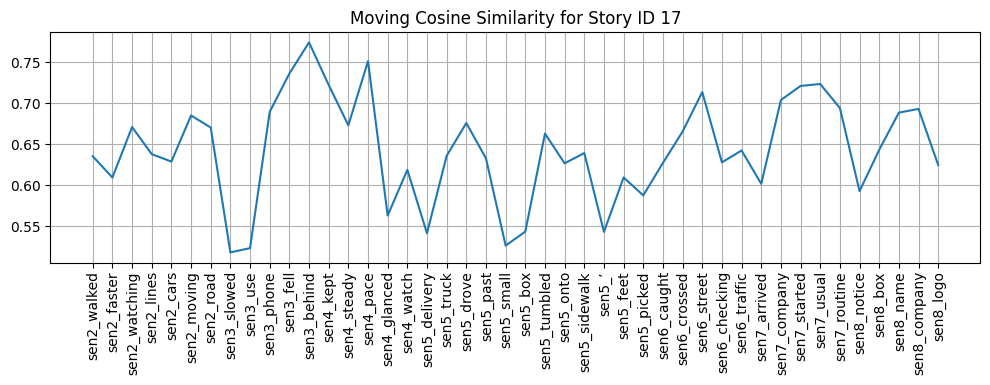

Story ID 17, sentence number of outlier at threshold 0.6093: [2, 3, 4, 5, 7, 8]
Story ID 17, sentence number of outlier at threshold 0.5618: [3, 5]






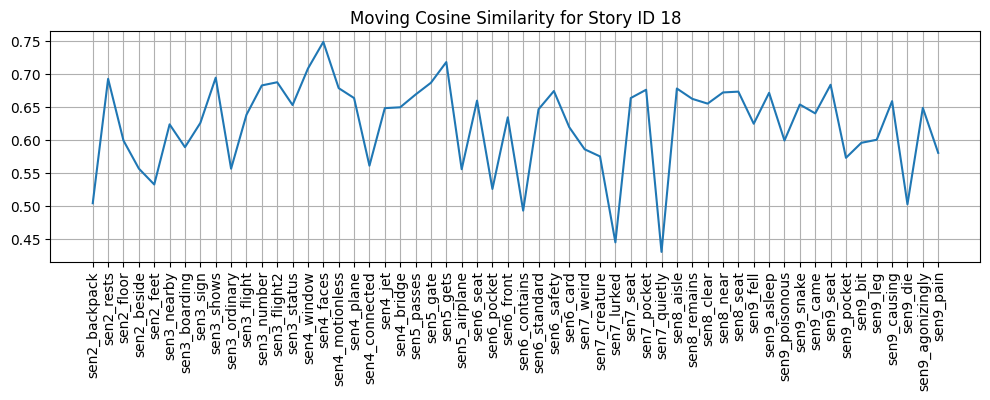

Story ID 18, sentence number of outlier at threshold 0.5842: [2, 3, 4, 5, 6, 7, 9]
Story ID 18, sentence number of outlier at threshold 0.5314: [2, 6, 7, 9]
Story ID 18, sentence number of outlier at threshold 0.4786: [7]






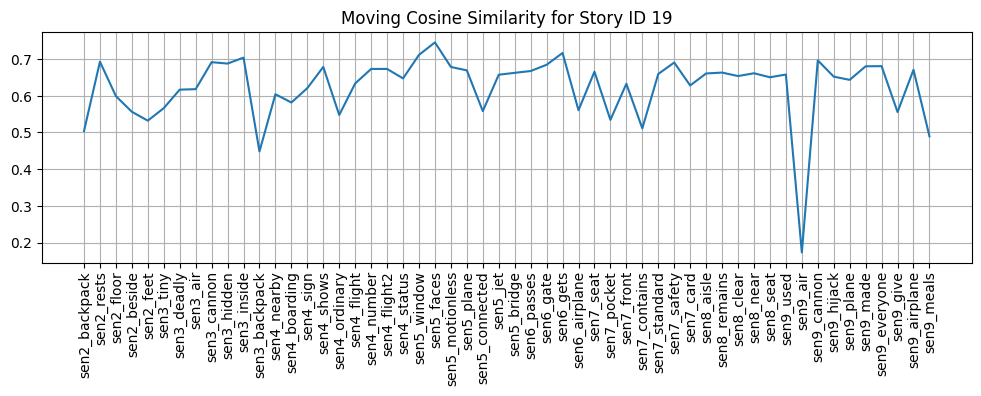

Story ID 19, sentence number of outlier at threshold 0.5858: [2, 3, 4, 5, 6, 7, 9]
Story ID 19, sentence number of outlier at threshold 0.5311: [2, 3, 7, 9]
Story ID 19, sentence number of outlier at threshold 0.4764: [3, 9]






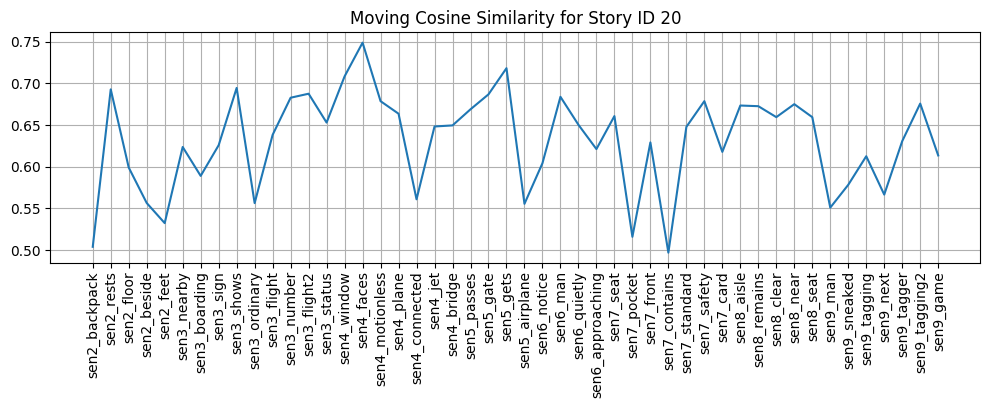

Story ID 20, sentence number of outlier at threshold 0.5963: [2, 3, 4, 5, 7, 9]
Story ID 20, sentence number of outlier at threshold 0.5491: [2, 7]






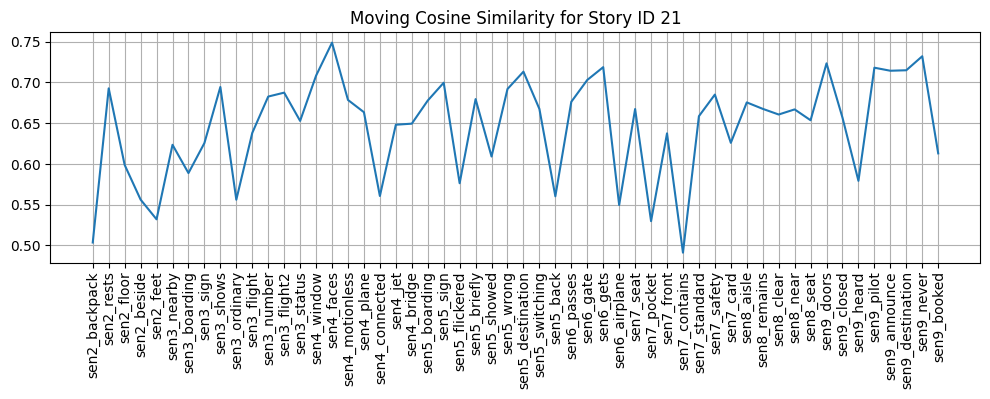

Story ID 21, sentence number of outlier at threshold 0.6100: [2, 3, 4, 5, 6, 7, 9]
Story ID 21, sentence number of outlier at threshold 0.5616: [2, 3, 4, 5, 6, 7]
Story ID 21, sentence number of outlier at threshold 0.5132: [2, 7]






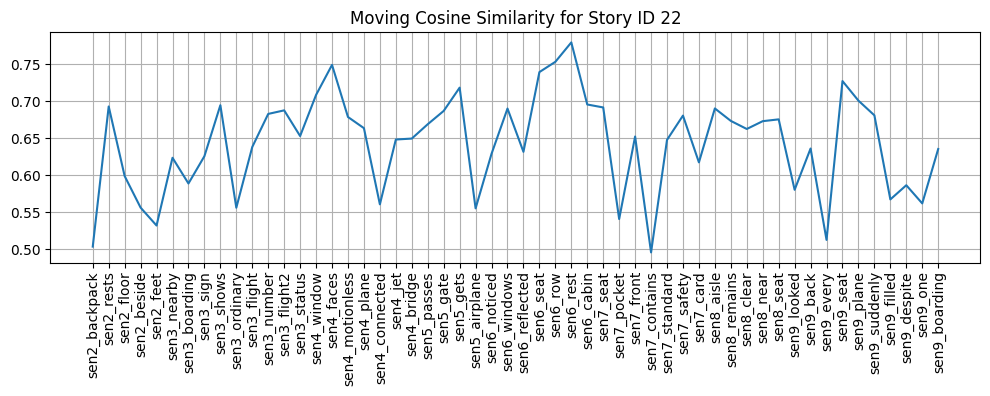

Story ID 22, sentence number of outlier at threshold 0.5913: [2, 3, 4, 5, 7, 9]
Story ID 22, sentence number of outlier at threshold 0.5325: [2, 7, 9]
Story ID 22, sentence number of outlier at threshold 0.4738: []






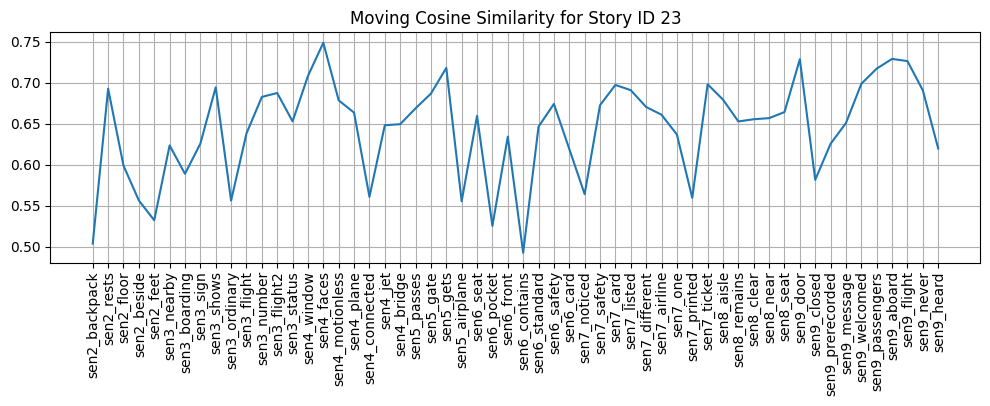

Story ID 23, sentence number of outlier at threshold 0.6196: [2, 3, 4, 5, 6, 7, 9]
Story ID 23, sentence number of outlier at threshold 0.5784: [2, 3, 4, 5, 6, 7]
Story ID 23, sentence number of outlier at threshold 0.5372: [2, 6]






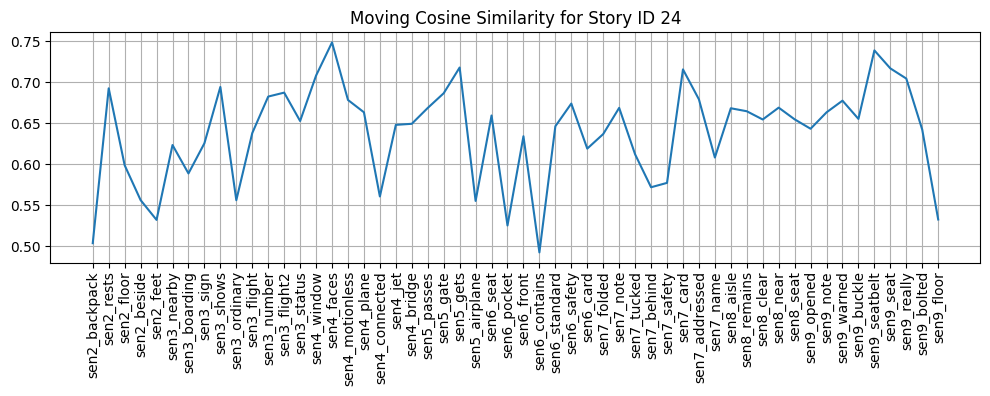

Story ID 24, sentence number of outlier at threshold 0.6092: [2, 3, 4, 5, 6, 7, 9]
Story ID 24, sentence number of outlier at threshold 0.5677: [2, 3, 4, 5, 6, 9]
Story ID 24, sentence number of outlier at threshold 0.5263: [2, 6]






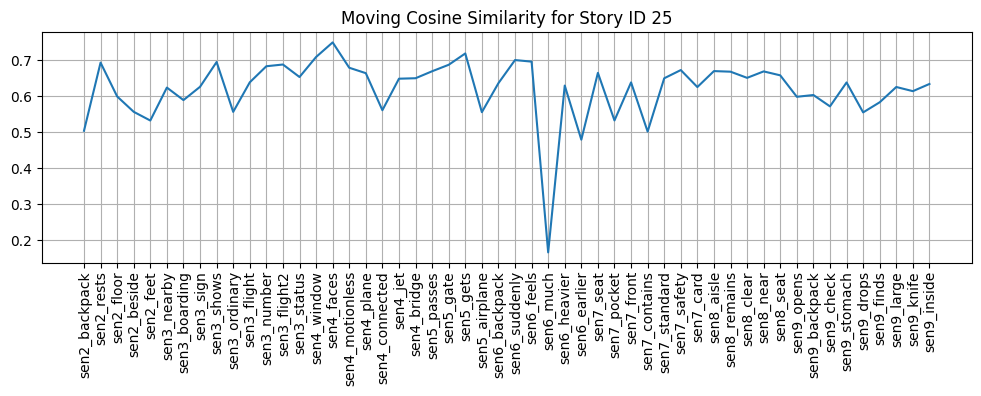

Story ID 25, sentence number of outlier at threshold 0.5873: [2, 3, 4, 5, 6, 7, 9]
Story ID 25, sentence number of outlier at threshold 0.5383: [2, 6, 7]
Story ID 25, sentence number of outlier at threshold 0.4894: [6]






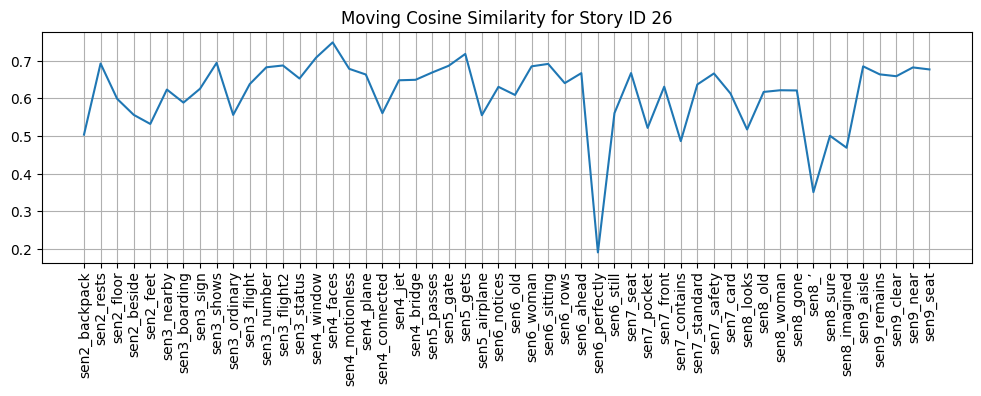

Story ID 26, sentence number of outlier at threshold 0.5609: [2, 3, 4, 5, 6, 7, 8]
Story ID 26, sentence number of outlier at threshold 0.4911: [6, 7, 8]
Story ID 26, sentence number of outlier at threshold 0.4213: [6, 8]






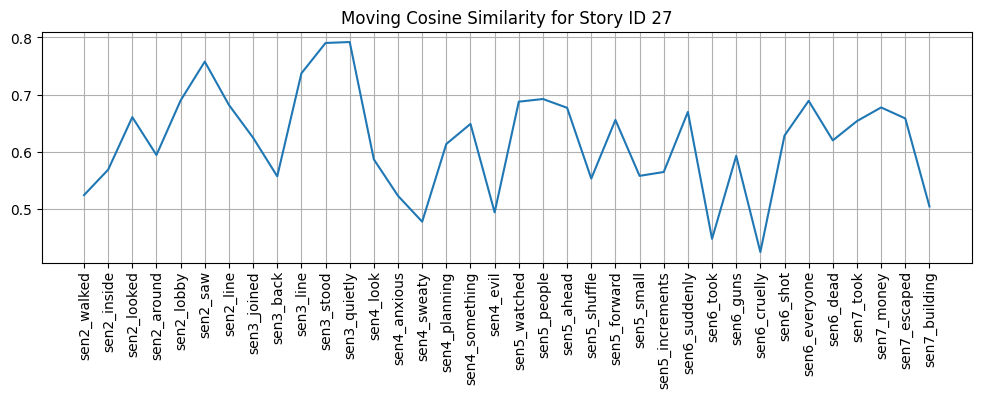

Story ID 27, sentence number of outlier at threshold 0.5579: [2, 3, 4, 5, 6, 7]
Story ID 27, sentence number of outlier at threshold 0.4854: [4, 6]






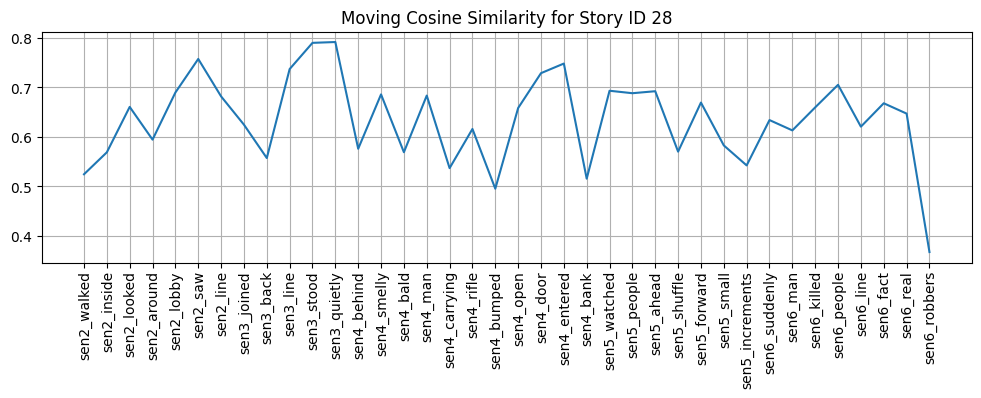

Story ID 28, sentence number of outlier at threshold 0.5717: [2, 3, 4, 5, 6]
Story ID 28, sentence number of outlier at threshold 0.5010: [4, 6]






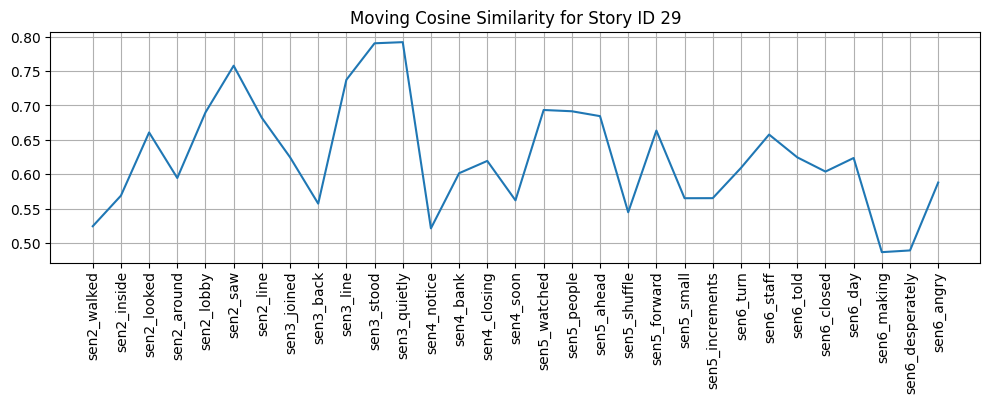

Story ID 29, sentence number of outlier at threshold 0.5652: [2, 3, 4, 5, 6]
Story ID 29, sentence number of outlier at threshold 0.4944: [6]






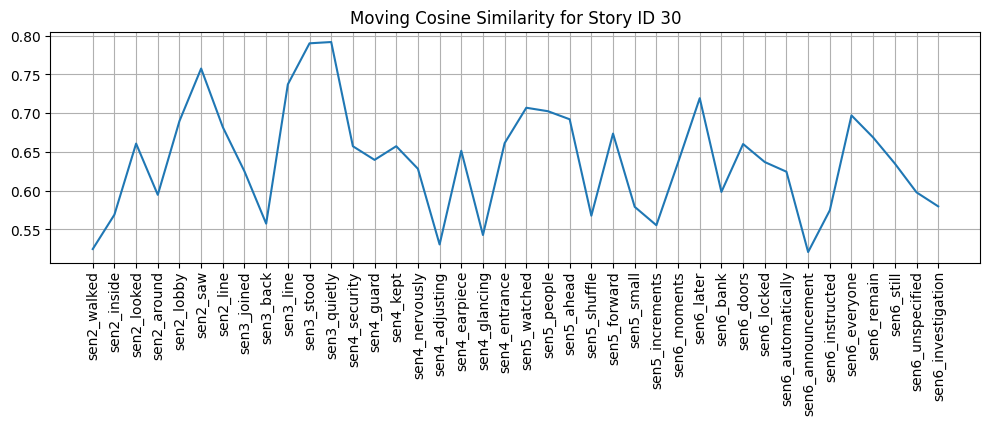

Story ID 30, sentence number of outlier at threshold 0.5794: [2, 3, 4, 5, 6]
Story ID 30, sentence number of outlier at threshold 0.5167: []






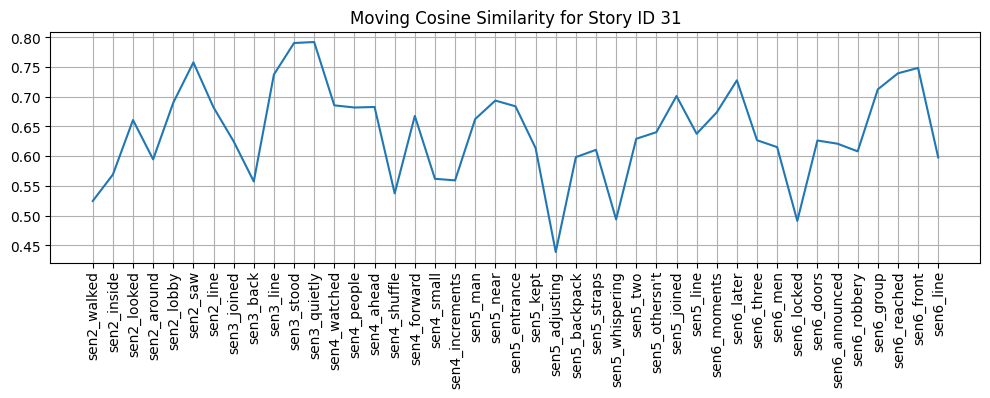

Story ID 31, sentence number of outlier at threshold 0.5980: [2, 3, 4, 5, 6]
Story ID 31, sentence number of outlier at threshold 0.5443: [2, 4, 5, 6]
Story ID 31, sentence number of outlier at threshold 0.4905: [5]






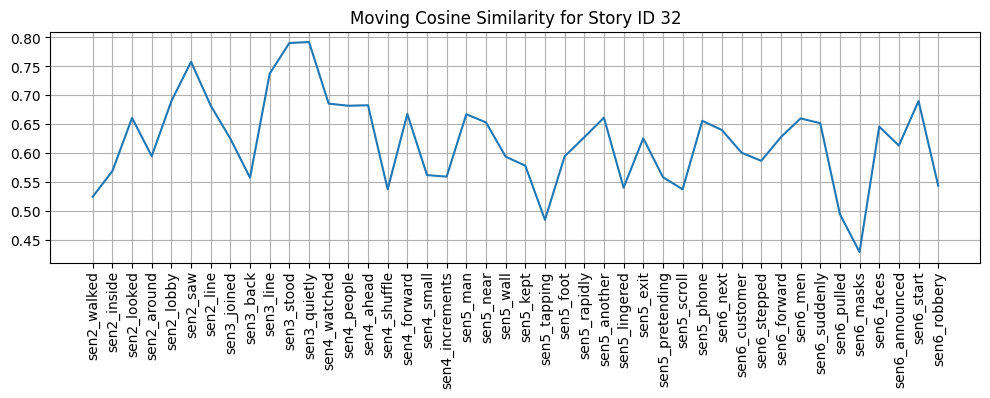

Story ID 32, sentence number of outlier at threshold 0.5611: [2, 3, 4, 5, 6]
Story ID 32, sentence number of outlier at threshold 0.4975: [5, 6]






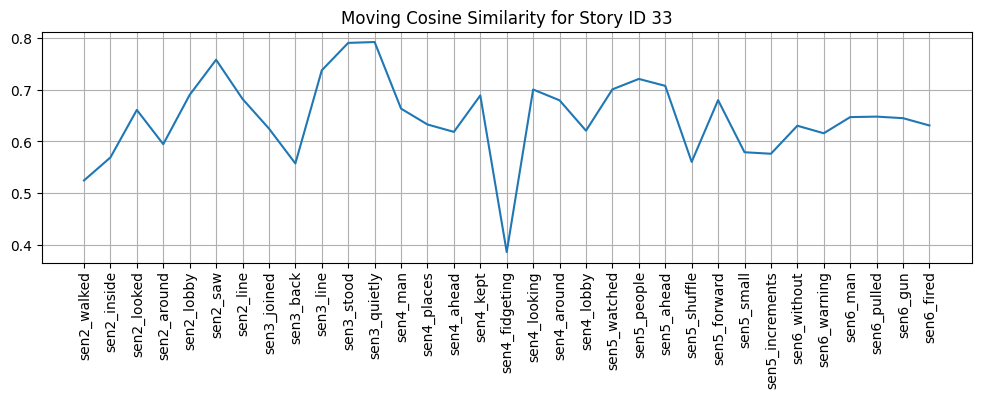

Story ID 33, sentence number of outlier at threshold 0.6156: [2, 3, 4, 5, 6]
Story ID 33, sentence number of outlier at threshold 0.5711: [2, 3, 4, 5]
Story ID 33, sentence number of outlier at threshold 0.5265: [2, 4]






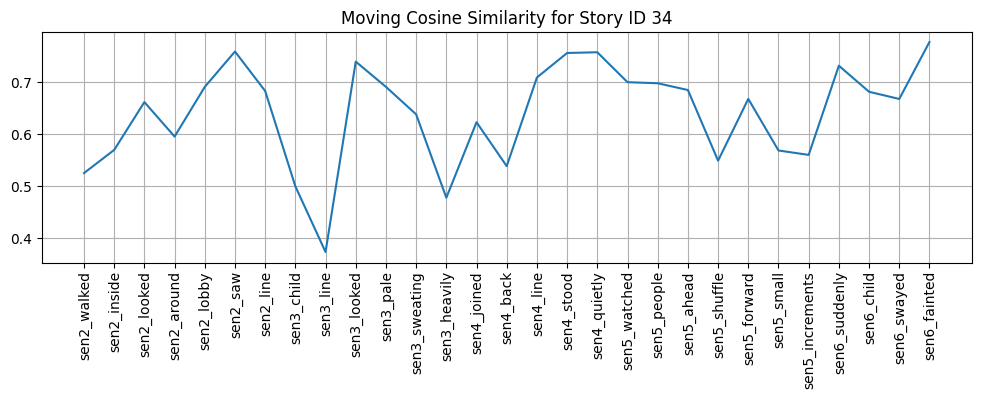

Story ID 34, sentence number of outlier at threshold 0.5678: [2, 3, 4, 5]
Story ID 34, sentence number of outlier at threshold 0.4892: [3]






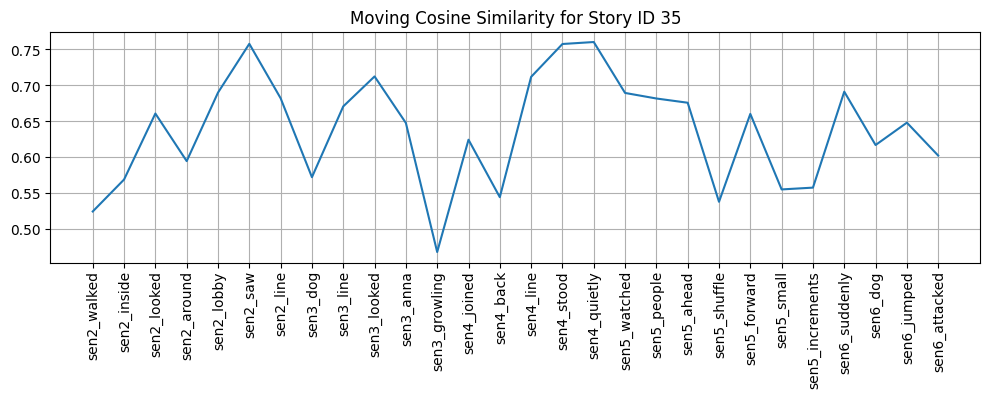

Story ID 35, sentence number of outlier at threshold 0.5713: [2, 3, 4, 5]
Story ID 35, sentence number of outlier at threshold 0.5004: [3]





Stories processed: 36
Stories with M ≠ 0: 24 (66.67%)


,M,A,B,Note
0,0.214679,0.398110,0.245926,restaurant
1,0.257584,0.525482,0.247269,restaurant
2,0.287876,0.428568,0.435061,restaurant
3,0.244961,0.333529,0.401353,restaurant
4,0.000000,0.000000,0.000000,restaurant
5,0.000000,0.000000,0.000000,restaurant
6,0.236380,0.398356,0.310785,restaurant
7,0.213682,0.341405,0.299640,restaurant
8,0.000000,0.000000,0.000000,restaurant
9,0.245281,0.363584,0.372260,work routine


In [ ]:
## BERT init, large-uncased model has 1024-dimension
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "bert-large-uncased"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_ID)
model = BertModel.from_pretrained(MODEL_ID).to(DEVICE).eval()


## Load Data
# concat all stories from III. Modified Stories
restaurant = restaurant_kyle + restaurant_cindy + restaurant_naharin
work_routine = work_routine_kyle + work_routine_cindy + work_routine_naharin
airport = airport_kyle + airport_cindy + airport_naharin
bank = bank_kyle + bank_cindy + bank_naharin
all_story = restaurant + work_routine + airport + bank

# single_story is for evaluating just one story
# overwrite single_story with your own story
single_story = ["""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
Behind them, a smelly, bald man carrying a rifle bumped open the door and entered the bank.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the man killed all the people in line because they are in fact the real robbers."""]


## HYPERPARAMS
story_set = all_story
# story_set = single_story
plot_mcs_yes = True # moving cosine similarity (mcs) graph
print_outlier_yes = True  # value of threshold of outlier selection algorithm
calculating_mcs_with_skipped_tokens = True  # whether include the first sentence when calculating mcs

result = story_set_run(story_set)

In [ ]:
## Analysis Phase I
df = pd.DataFrame(result, columns=["M","A","B","Note"])
df_restaurant = df[df["Note"]=="restaurant"]
df_work_routine = df[df["Note"]=="work routine"]
df_airport = df[df["Note"]=="airport"]
df_bank = df[df["Note"]=="bank"]

# display(df_restaurant)
# display(df_work_routine)
# display(df_airport)
# display(df_bank)

print(f"\nTotal Processed Story: {len(df)}\n")

# ratio of M ≠ 0 stories (M≠0 stories / total stories)
ratio_restaurant = (df_restaurant["M"] > 0).sum() / len(df_restaurant)
ratio_work_routine = (df_work_routine["M"] > 0).sum() / len(df_work_routine)
ratio_airport = (df_airport["M"] > 0).sum() / len(df_airport)
ratio_bank = (df_bank["M"] > 0).sum() / len(df_bank)
ratio_overall = (df["M"] > 0).sum() / len(df)
print(f'M ≠ 0 Ratio of Restaurant Story: {ratio_restaurant:.0%} ({(df_restaurant["M"]>0).sum()}/{len(df_restaurant)})')
print(f'M ≠ 0 Ratio of Work Routine Story: {ratio_work_routine:.0%} ({(df_work_routine["M"]>0).sum()}/{len(df_work_routine)})')
print(f'M ≠ 0 Ratio of Airport Story: {ratio_airport:.0%} ({(df_airport["M"]>0).sum()}/{len(df_airport)})')
print(f'M ≠ 0 Ratio of Bank Story: {ratio_bank:.0%} ({(df_bank["M"]>0).sum()}/{len(df_bank)})')
print(f'>> Overall Ratio: {ratio_overall:.0%} ({(df["M"]>0).sum()}/{len(df)})\n')

# mean M value of M ≠ 0 stories
M_restaurant = df_restaurant[df_restaurant["M"] > 0]["M"].mean()
M_work_routine = df_work_routine[df_work_routine["M"] > 0]["M"].mean()
M_airport = df_airport[df_airport["M"] > 0]["M"].mean()
M_bank = df_bank[df_bank["M"] > 0]["M"].mean()
M_overall = df[df["M"] > 0]["M"].mean()
print(f'Mean M Value of Restaurant Story: {M_restaurant:.2f}')
print(f'Mean M Value of Work Routine Story: {M_work_routine:.2f}')
print(f'Mean M Value of Airport Story: {M_airport:.2f}')
print(f'Mean M Value of Bank Story: {M_bank:.2f}')
print(f'>> Overall Mean M Value: {M_overall:.2f}')




Total Processed Story: 36

M ≠ 0 Ratio of Restaurant Story: 67% (6/9)
M ≠ 0 Ratio of Work Routine Story: 89% (8/9)
M ≠ 0 Ratio of Airport Story: 67% (6/9)
M ≠ 0 Ratio of Bank Story: 44% (4/9)
>> Overall Ratio: 67% (24/36)

Mean M Value of Restaurant Story: 0.24
Mean M Value of Work Routine Story: 0.24
Mean M Value of Airport Story: 0.23
Mean M Value of Bank Story: 0.20
>> Overall Mean M Value: 0.23


In [ ]:
## Analysis Phase II - Select Highest and Lowest M Value Stories

display(df[df["M"] > 0])
restaurant_max_id = df[(df["M"] > 0) & (df["Note"]=="restaurant")]["M"].idxmax()
restaurant_min_id = df[(df["M"] > 0) & (df["Note"]=="restaurant")]["M"].idxmin()
restaurant_max_val = df[(df["M"] > 0) & (df["Note"]=="restaurant")]["M"].max()
restaurant_min_val = df[(df["M"] > 0) & (df["Note"]=="restaurant")]["M"].min()
print(f'\n>> Max M of Restaurant Story: {restaurant_max_val:.4f} (story ID #{restaurant_max_id}) <<\n{all_story[restaurant_max_id]}\n')
print(f'\n>> Min M of Restaurant Story: {restaurant_min_val:.4f} (story ID #{restaurant_min_id}) <<\n{all_story[restaurant_min_id]}\n')

work_routine_max_id = df[(df["M"] > 0) & (df["Note"]=="work routine")]["M"].idxmax()
work_routine_min_id = df[(df["M"] > 0) & (df["Note"]=="work routine")]["M"].idxmin()
work_routine_max_val = df[(df["M"] > 0) & (df["Note"]=="work routine")]["M"].max()
work_routine_min_val = df[(df["M"] > 0) & (df["Note"]=="work routine")]["M"].min()
print(f'\n>> Max M of Work Routine Story: {work_routine_max_val:.4f} (story ID #{work_routine_max_id}) <<\n{all_story[work_routine_max_id]}\n')
print(f'\n>> Min M of Work Routine Story: {work_routine_min_val:.4f} (story ID #{work_routine_min_id}) <<\n{all_story[work_routine_min_id]}\n')

airport_max_id = df[(df["M"] > 0) & (df["Note"]=="airport")]["M"].idxmax()
airport_min_id = df[(df["M"] > 0) & (df["Note"]=="airport")]["M"].idxmin()
airport_max_val = df[(df["M"] > 0) & (df["Note"]=="airport")]["M"].max()
airport_min_val = df[(df["M"] > 0) & (df["Note"]=="airport")]["M"].min()
print(f'\n>> Max M of Airport Story: {airport_max_val:.4f} (story ID #{airport_max_id}) <<\n{all_story[airport_max_id]}\n')
print(f'\n>> Min M of Airport Story: {airport_min_val:.4f} (story ID #{airport_min_id}) <<\n{all_story[airport_min_id]}\n')

bank_max_id = df[(df["M"] > 0) & (df["Note"]=="bank")]["M"].idxmax()
bank_min_id = df[(df["M"] > 0) & (df["Note"]=="bank")]["M"].idxmin()
bank_max_val = df[(df["M"] > 0) & (df["Note"]=="bank")]["M"].max()
bank_min_val = df[(df["M"] > 0) & (df["Note"]=="bank")]["M"].min()
print(f'\n>> Max M of Bank Story: {bank_max_val:.4f} (story ID #{bank_max_id}) <<\n{all_story[bank_max_id]}\n')
print(f'\n>> Min M of Bank Story: {bank_min_val:.4f} (story ID #{bank_min_id}) <<\n{all_story[bank_min_id]}\n')



,M,A,B,Note
0,0.214679,0.398110,0.245926,restaurant
1,0.257584,0.525482,0.247269,restaurant
2,0.287876,0.428568,0.435061,restaurant
3,0.244961,0.333529,0.401353,restaurant
6,0.236380,0.398356,0.310785,restaurant
7,0.213682,0.341405,0.299640,restaurant
9,0.245281,0.363584,0.372260,work routine
10,0.182075,0.334543,0.211681,work routine
11,0.304964,0.424027,0.490865,work routine
12,0.237514,0.207482,0.505060,work routine



>> Max M of Restaurant Story: 0.2879 (story ID #2) <<
Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
The waiter secretly added an unknown powder to their food without being noticed.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
On their way home, the powder began to take effect, swapping their souls.


>> Min M of Restaurant Story: 0.2137 (story ID #7) <<
Sam and Judy went out for dinner at their favorite restaurant.
On their way out the door, Sam noticed their porch light flicker twice, though the power in the house was fine.
While driving to the restaurant, Judy's favorite song played on the radio.
S

In [ ]:
## Analysis Phase II - Likert Rating & One-tailed Wilcoxon Signed Rank Test

rating_kyle = [4,1,4,4,2,4,3,2]
rating_cindy = [2,1,5,2,3,3,4,2]
rating_naharin = [3,4,4,3,5,3,5,5]

rating_restaurant_high = np.array([rating_kyle[0], rating_cindy[0], rating_naharin[0]]) # 4,2,3
rating_restaurant_low = np.array([rating_kyle[1], rating_cindy[1], rating_naharin[1]]) # 1,1,4
rating_work_routine_high = np.array([rating_kyle[2], rating_cindy[2], rating_naharin[2]]) # 4,5,4
rating_work_routine_low = np.array([rating_kyle[3], rating_cindy[3], rating_naharin[3]]) # 4,2,3
rating_airport_high = np.array([rating_kyle[4], rating_cindy[4], rating_naharin[4]]) # 2,3,5
rating_airport_low = np.array([rating_kyle[5], rating_cindy[5], rating_naharin[5]]) # 4,3,3
rating_bank_high = np.array([rating_kyle[6], rating_cindy[6], rating_naharin[6]]) # 3,4,5
rating_bank_low = np.array([rating_kyle[7], rating_cindy[7], rating_naharin[7]]) # 2,2,5
print(f'restaurant, High-M // mean {np.mean(rating_restaurant_high):.2f} // median {np.median(rating_restaurant_high):.0f}')
print(f'restaurant, Low-M // mean {np.mean(rating_restaurant_low):.2f} // median {np.median(rating_restaurant_low):.0f}')
print(f'work_routine, High-M // mean {np.mean(rating_work_routine_high):.2f} // median {np.median(rating_work_routine_high):.0f}')
print(f'work_routine, Low-M // mean {np.mean(rating_work_routine_low):.2f} // median {np.median(rating_work_routine_low):.0f}')
print(f'airport, High-M // mean {np.mean(rating_airport_high):.2f} // median {np.median(rating_airport_high):.0f}')
print(f'airport, Low-M // mean {np.mean(rating_airport_low):.2f} // median {np.median(rating_airport_low):.0f}')
print(f'bank, High-M // mean {np.mean(rating_bank_high):.2f} // median {np.median(rating_bank_high):.0f}')
print(f'bank, Low-M // mean {np.mean(rating_bank_low):.2f} // median {np.median(rating_bank_low):.0f}\n')

# decide checking direction
# Null Hypothesis (H0): The median of the differences is zero.
# The median of the differences (high - low) is less than zero (e.g., intervention decreased values) >>> alternative='less'
# The median of the differences (high - low) is greater than zero (e.g., intervention increased values >>> alternative='greater'
alternative_restaurant = 'greater' # median (differences (high-low)) = median(3,1,-1)>0 >>> greater
alternative_work_routine = 'greater' # median (differences (high-low)) = median(0,3,1)>0  >>> greater
alternative_airport = 'less' # median (differences (high-low)) = median(-2,0,2)=0  >>> less or greater
alternative_bank = 'greater' # median (differences (high-low)) = median(1,2,0)>0  >>> greater

# get p value
statistic_restaurant, p_value_restaurant = stats.wilcoxon(x=rating_restaurant_high, y=rating_restaurant_low, alternative=alternative_restaurant)
statistic_work_routine, p_value_work_routine = stats.wilcoxon(x=rating_work_routine_high, y=rating_work_routine_low, alternative=alternative_work_routine)
statistic_airport, p_value_airport = stats.wilcoxon(x=rating_airport_high, y=rating_airport_low, alternative=alternative_airport)
statistic_bank, p_value_bank = stats.wilcoxon(x=rating_bank_high, y=rating_bank_low, alternative=alternative_bank)
print(f'restaurant story p-value (alternative={alternative_restaurant}): {p_value_restaurant}')
print(f'work routine p-value (alternative={alternative_work_routine}): {p_value_work_routine}')
print(f'airport p-value (alternative={alternative_airport}): {p_value_airport}')
print(f'bank p-value (alternative={alternative_bank}): {p_value_bank}')





restaurant, High-M // mean 3.00 // median 3
restaurant, Low-M // mean 2.00 // median 1
work_routine, High-M // mean 4.33 // median 4
work_routine, Low-M // mean 3.00 // median 3
airport, High-M // mean 3.33 // median 3
airport, Low-M // mean 3.33 // median 3
bank, High-M // mean 4.00 // median 4
bank, Low-M // mean 3.00 // median 2

restaurant story p-value (alternative=greater): 0.375
work routine p-value (alternative=greater): 0.25
airport p-value (alternative=less): 0.75
bank p-value (alternative=greater): 0.25


In [ ]:
## Reference Only
## Highest and Lowest M Stories
"""
>> Max M of Restaurant Story: 0.2879 (story ID #2) <<
== Story #1 ==
Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
The waiter secretly added an unknown powder to their food without being noticed.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
On their way home, the powder began to take effect, swapping their souls.


>> Min M of Restaurant Story: 0.2137 (story ID #7) <<
==   Story #2   ==
Sam and Judy went out for dinner at their favorite restaurant.
On their way out the door, Sam noticed their porch light flicker twice, though the power in the house was fine.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
As they stood to leave the restaurant, Judy realized her phone had recorded a call she never made from a number matching their home address.
They paid their tab, left a tip for the waiter, and drove back home.


>> Max M of Work Routine Story: 0.3050 (story ID #11) <<
==   Story #3   ==
Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A little puppy followed them along without being noticed.
They arrived at the company and started their usual routine.
When they got off work, they saw the puppy waiting patiently at the company entrance.
They decided to take in the puppy as their pet, and they lived happily ever after.


>> Min M of Work Routine Story: 0.1821 (story ID #10) <<
==   Story #4   ==
Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
She did not watch the road and was tripped by a huge pothole, causing her knee to bleed.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Tina's wound was infected by an alien virus and she turned into a intimidating zombie.


>> Max M of Airport Story: 0.2519 (story ID #26) <<
==   Story #5   ==
Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number and a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
He notices an old woman sitting a few rows ahead, perfectly still.
The seat pocket in front of Jordan contains the standard safety card.
When he looks up again, the old woman is gone, and Jordan isn’t sure if he imagined her.
The aisle remains clear near Jordan's seat.


>> Min M of Airport Story: 0.2040 (story ID #21) <<
==   Story #6   ==
Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
The boarding sign flickered once and briefly showed the wrong destination before switching back.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
As the doors closed, Jordan heard the pilot announce a destination he had never booked.


>> Max M of Bank Story: 0.2365 (story ID #27) <<
==   Story #7   ==
Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They look anxious and sweaty because they are planning something evil.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, they took out guns and cruelly shot everyone dead.
They took all the money and escaped the building.


>> Min M of Bank Story: 0.1633 (story ID #28) <<
==   Story #8   ==
Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
Behind them, a smelly, bald man carrying a rifle bumped open the door and entered the bank.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the man killed all the people in line because they are in fact the real robbers.

"""

"\n>> Max M of Restaurant Story: 0.2879 (story ID #2) <<\n== Story #1 ==\nSam and Judy went out for dinner at their favorite restaurant.\nWhile driving to the restaurant, Judy's favorite song played on the radio.\nSam found a parking space at the very front of the restaurant.\nSam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.\nSam's favorite song played on the radio while they waited for their food.\nThe waiter secretly added an unknown powder to their food without being noticed.\nSam and Judy enjoyed their meal.\nThey paid their tab, left a tip for the waiter, and drove back home.\nOn their way home, the powder began to take effect, swapping their souls.\n\n\n>> Min M of Restaurant Story: 0.2137 (story ID #7) <<\n==   Story #2   ==\nSam and Judy went out for dinner at their favorite restaurant.\nOn their way out the door, Sam noticed their porch light flicker twice, though the power in the house was fine.\nWhile driving to the re

## V. Evaluation: ModernBERT

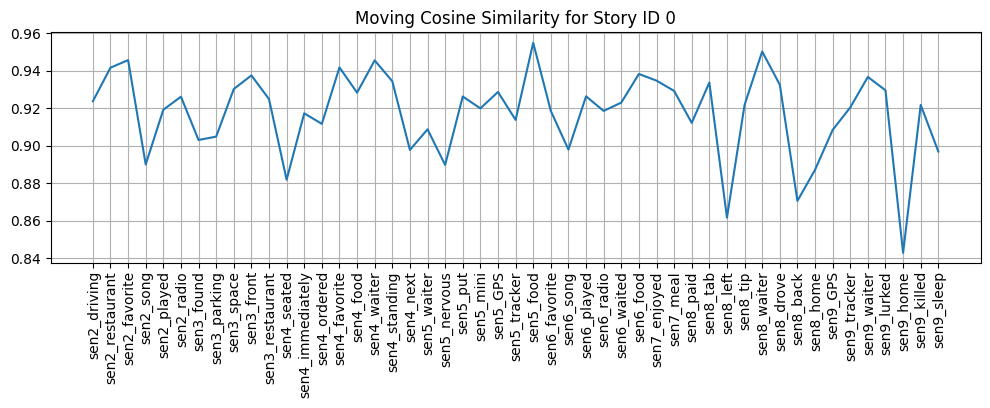

Story ID 0, sentence number of outlier at threshold 0.9083: [2, 3, 4, 5, 6, 8, 9]
Story ID 0, sentence number of outlier at threshold 0.8938: [2, 4, 5, 8, 9]
Story ID 0, sentence number of outlier at threshold 0.8794: [8, 9]






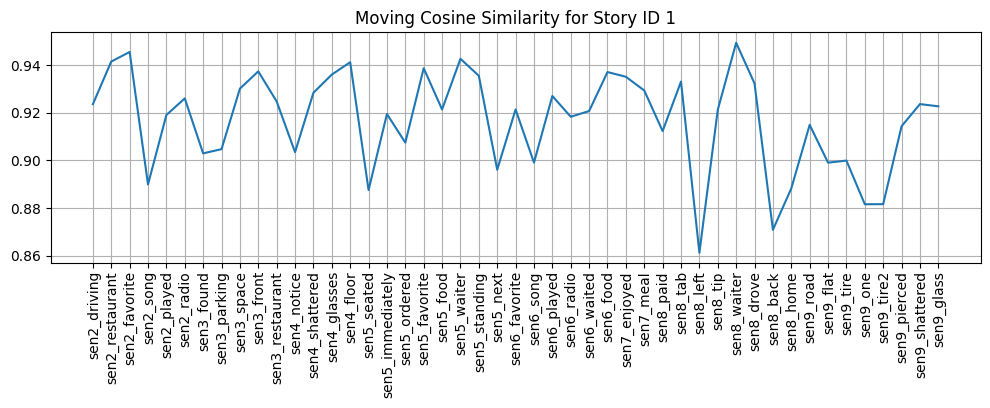

Story ID 1, sentence number of outlier at threshold 0.9032: [2, 3, 5, 6, 8, 9]
Story ID 1, sentence number of outlier at threshold 0.8855: [8, 9]






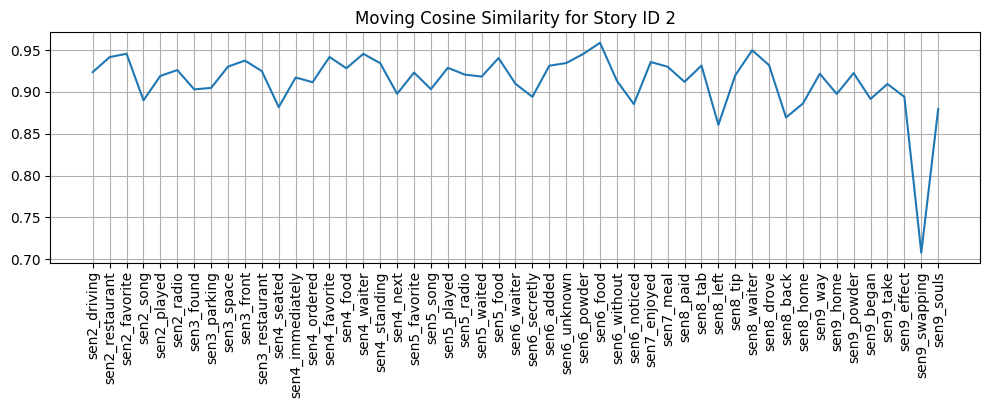

Story ID 2, sentence number of outlier at threshold 0.9003: [2, 4, 6, 8, 9]
Story ID 2, sentence number of outlier at threshold 0.8815: [8, 9]






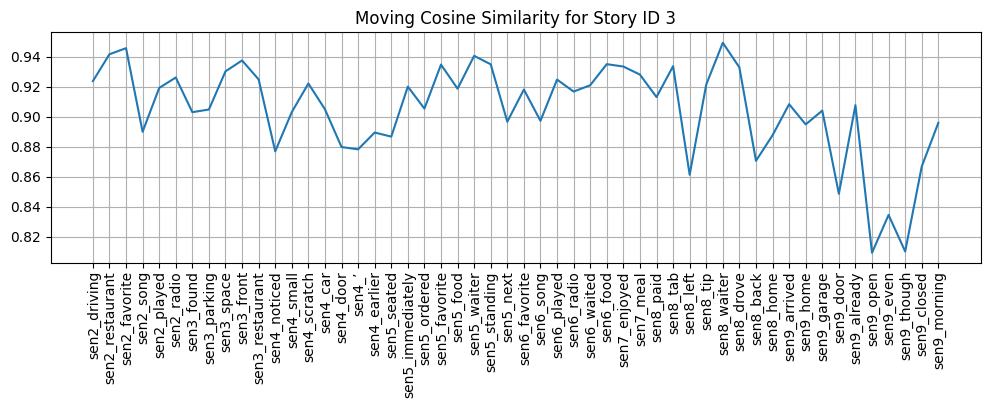

Story ID 3, sentence number of outlier at threshold 0.8898: [4, 5, 8, 9]
Story ID 3, sentence number of outlier at threshold 0.8678: [8, 9]






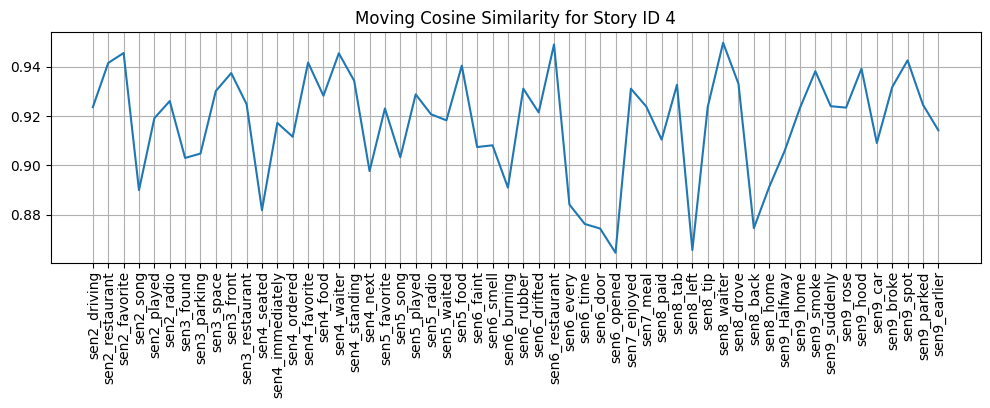

Story ID 4, sentence number of outlier at threshold 0.9055: [2, 3, 4, 5, 6, 8]
Story ID 4, sentence number of outlier at threshold 0.8897: [4, 6, 8]
Story ID 4, sentence number of outlier at threshold 0.8738: [6, 8]






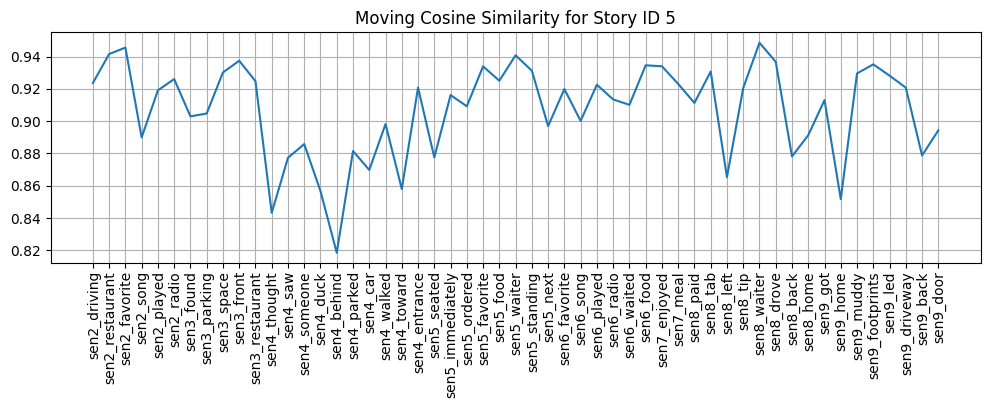

Story ID 5, sentence number of outlier at threshold 0.8899: [2, 4, 5, 8, 9]
Story ID 5, sentence number of outlier at threshold 0.8662: [4, 8, 9]
Story ID 5, sentence number of outlier at threshold 0.8424: [4]






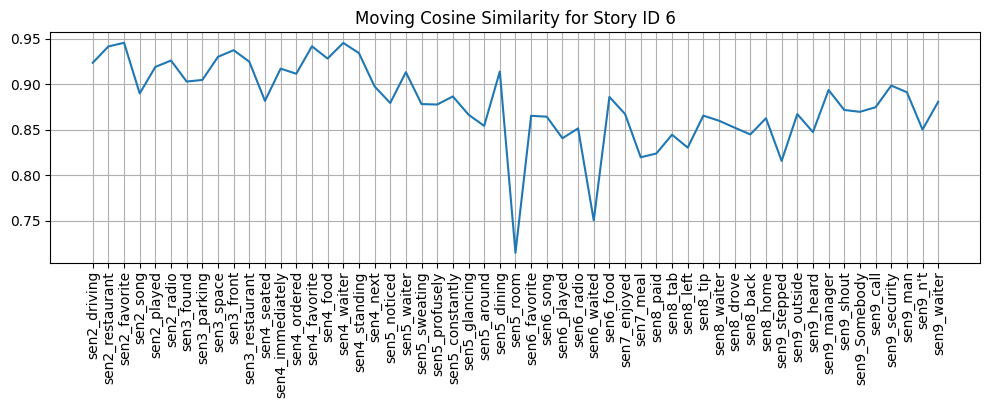

Story ID 6, sentence number of outlier at threshold 0.8572: [5, 6, 7, 8, 9]
Story ID 6, sentence number of outlier at threshold 0.8233: [5, 6, 7, 9]
Story ID 6, sentence number of outlier at threshold 0.7894: [5, 6]






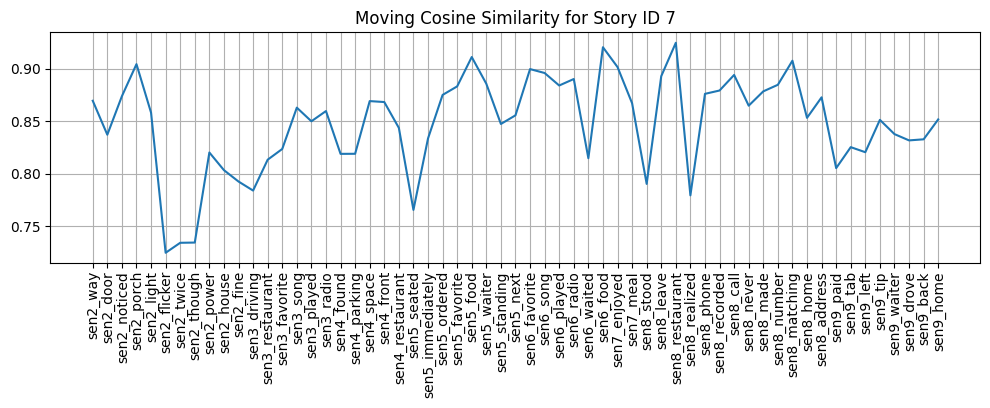

Story ID 7, sentence number of outlier at threshold 0.8204: [2, 3, 4, 5, 6, 8, 9]
Story ID 7, sentence number of outlier at threshold 0.7838: [2, 5, 8]
Story ID 7, sentence number of outlier at threshold 0.7472: [2]






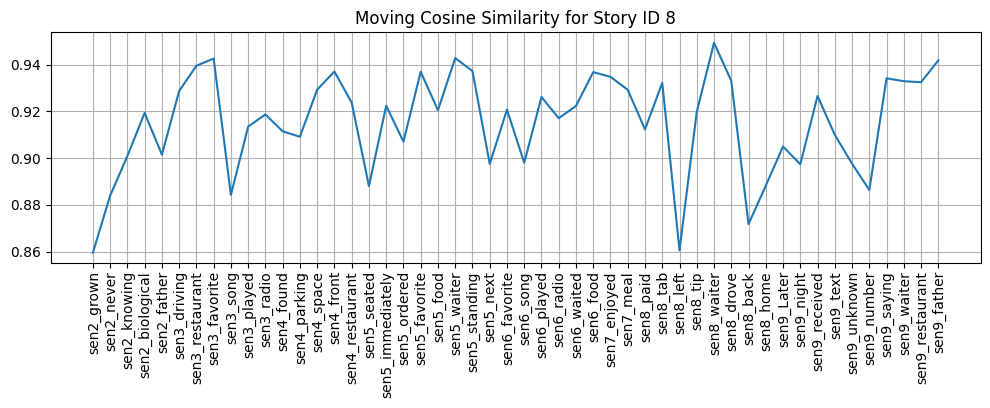

Story ID 8, sentence number of outlier at threshold 0.9010: [2, 3, 5, 6, 8, 9]
Story ID 8, sentence number of outlier at threshold 0.8819: [2, 8]






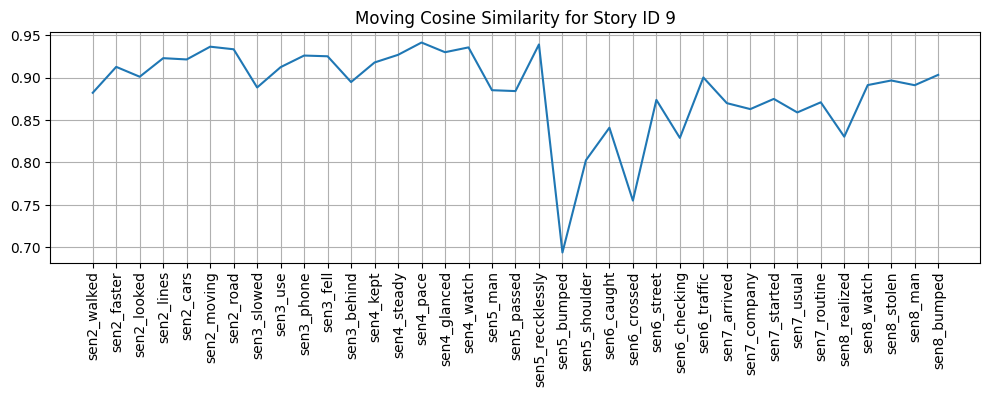

Story ID 9, sentence number of outlier at threshold 0.8709: [5, 6, 7, 8]
Story ID 9, sentence number of outlier at threshold 0.8397: [5, 6, 8]
Story ID 9, sentence number of outlier at threshold 0.8085: [5, 6]






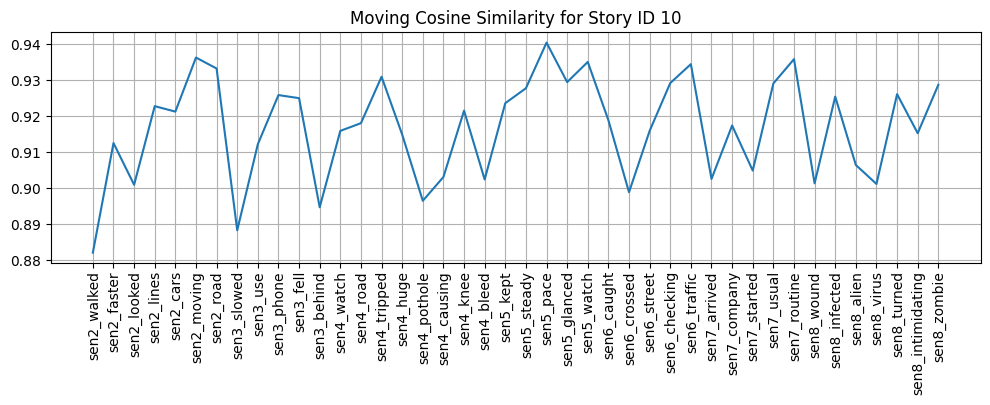

Story ID 10, sentence number of outlier at threshold 0.9036: [2, 3, 4, 6, 7, 8]
Story ID 10, sentence number of outlier at threshold 0.8886: [2, 3]






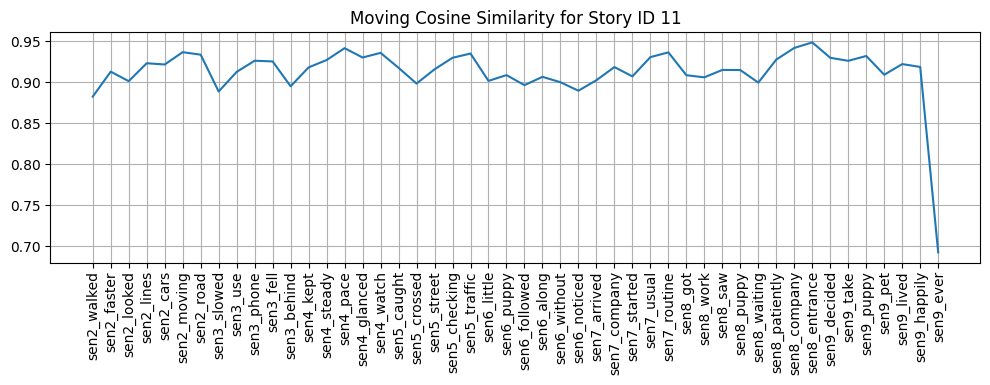

Story ID 11, sentence number of outlier at threshold 0.9047: [2, 3, 5, 6, 7, 8, 9]
Story ID 11, sentence number of outlier at threshold 0.8899: [2, 3, 6, 9]
Story ID 11, sentence number of outlier at threshold 0.8751: [9]






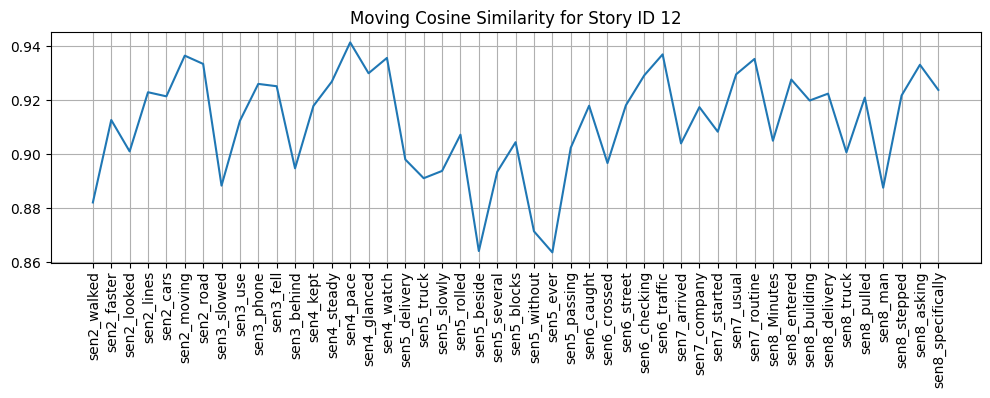

Story ID 12, sentence number of outlier at threshold 0.8993: [2, 3, 5, 6, 8]
Story ID 12, sentence number of outlier at threshold 0.8831: [2, 5]






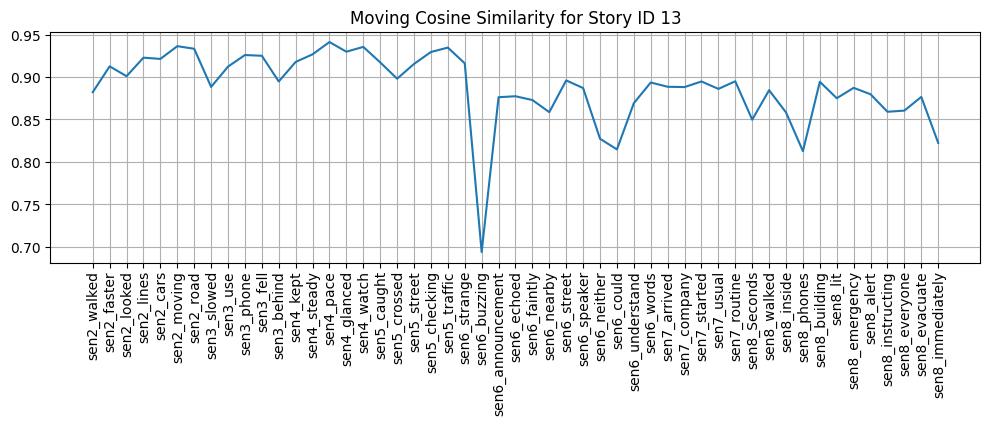

Story ID 13, sentence number of outlier at threshold 0.8756: [6, 8]






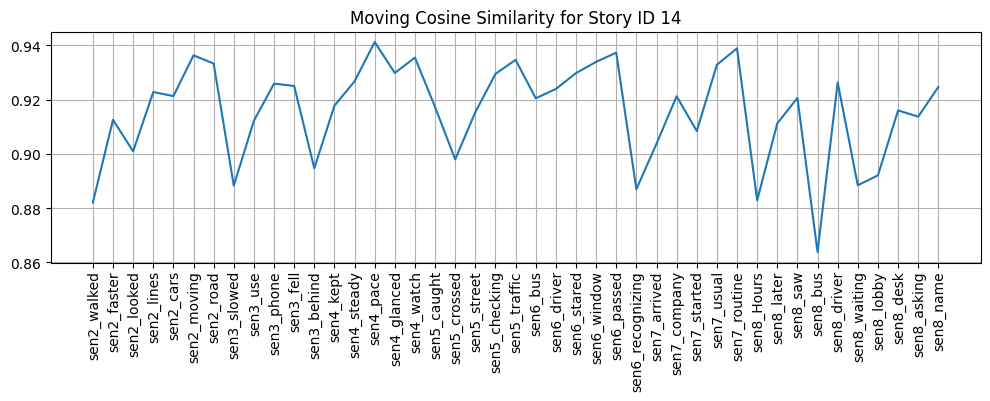

Story ID 14, sentence number of outlier at threshold 0.9061: [2, 3, 5, 6, 7, 8]
Story ID 14, sentence number of outlier at threshold 0.8920: [2, 3, 6, 8]
Story ID 14, sentence number of outlier at threshold 0.8779: [8]






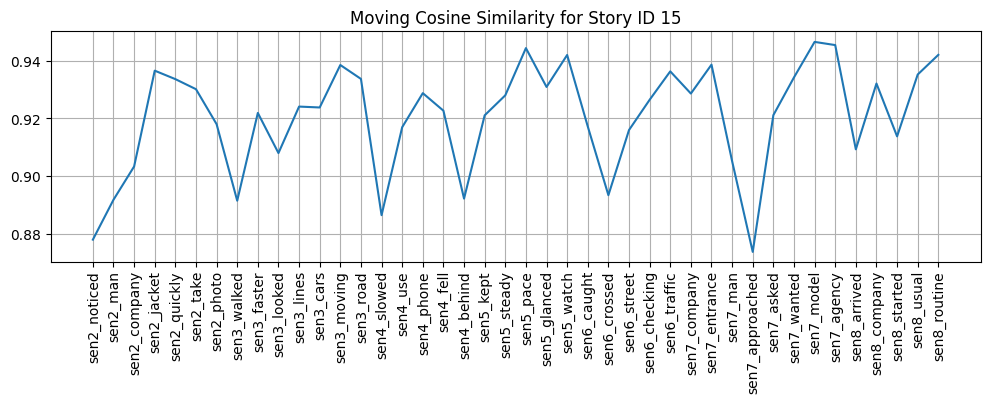

Story ID 15, sentence number of outlier at threshold 0.9104: [2, 3, 4, 6, 7, 8]
Story ID 15, sentence number of outlier at threshold 0.8961: [2, 3, 4, 6, 7]
Story ID 15, sentence number of outlier at threshold 0.8819: [2, 7]






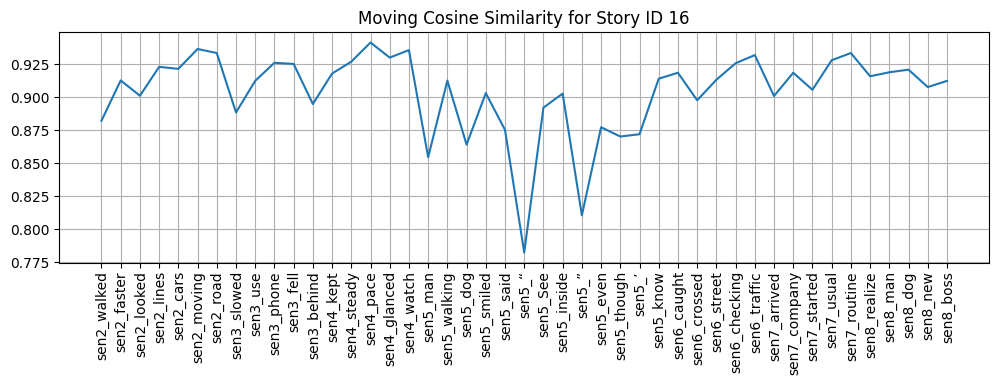

Story ID 16, sentence number of outlier at threshold 0.8947: [2, 3, 5]
Story ID 16, sentence number of outlier at threshold 0.8765: [5]






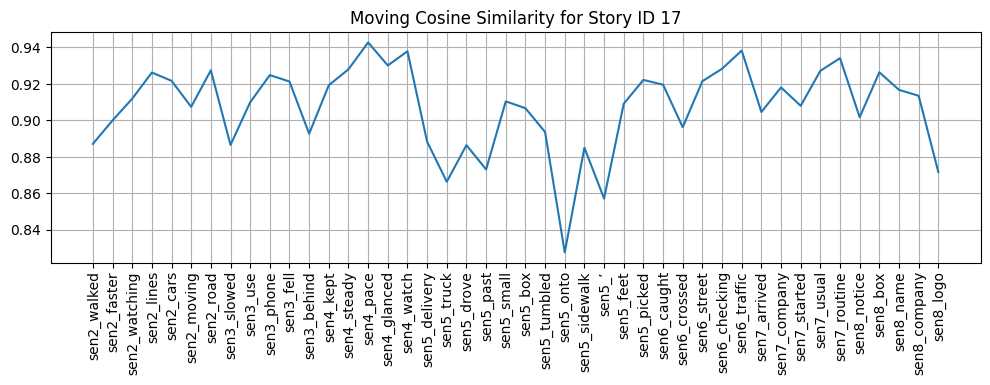

Story ID 17, sentence number of outlier at threshold 0.8933: [2, 3, 5, 8]
Story ID 17, sentence number of outlier at threshold 0.8742: [5, 8]






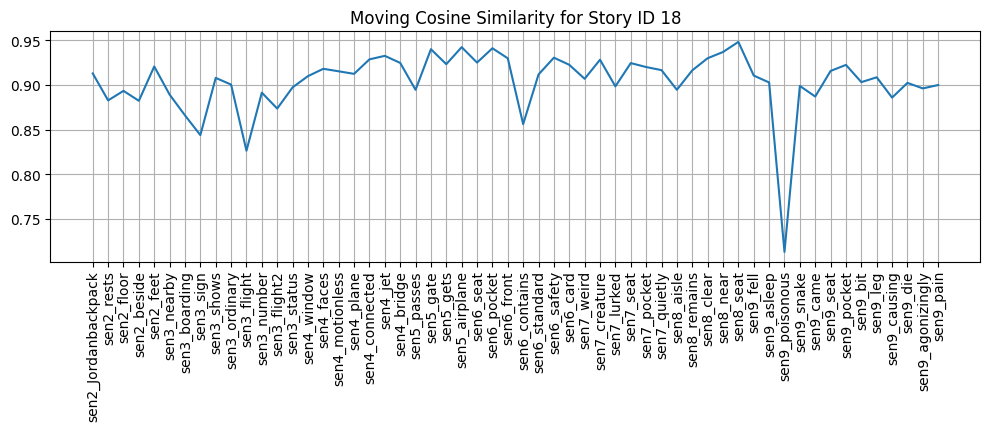

Story ID 18, sentence number of outlier at threshold 0.8946: [2, 3, 5, 6, 9]
Story ID 18, sentence number of outlier at threshold 0.8772: [3, 6, 9]
Story ID 18, sentence number of outlier at threshold 0.8598: [3, 6, 9]
Story ID 18, sentence number of outlier at threshold 0.8423: [3, 9]






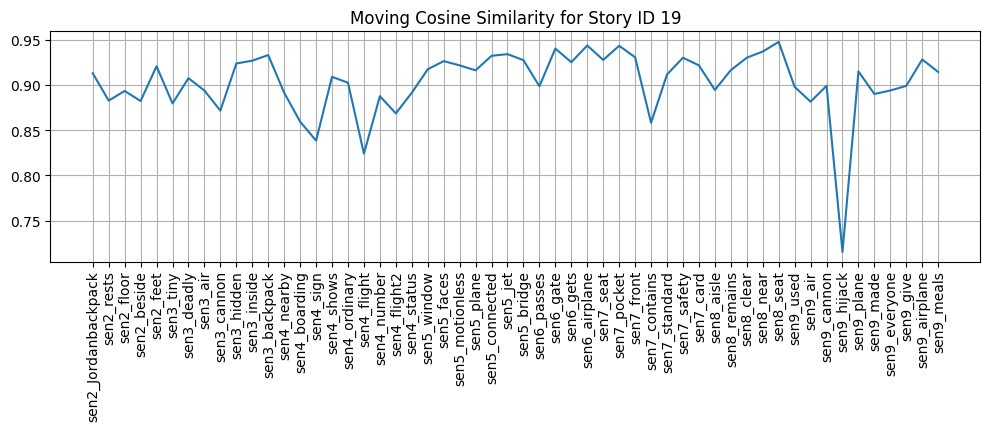

Story ID 19, sentence number of outlier at threshold 0.8914: [2, 3, 4, 7, 9]
Story ID 19, sentence number of outlier at threshold 0.8698: [4, 7, 9]
Story ID 19, sentence number of outlier at threshold 0.8483: [4, 9]






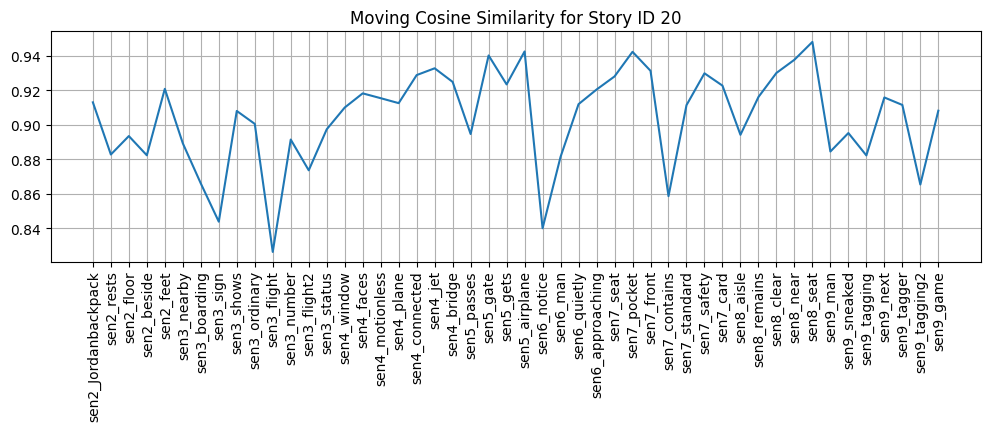

Story ID 20, sentence number of outlier at threshold 0.8880: [2, 3, 6, 7, 9]
Story ID 20, sentence number of outlier at threshold 0.8666: [3, 6, 7, 9]
Story ID 20, sentence number of outlier at threshold 0.8452: [3, 6]






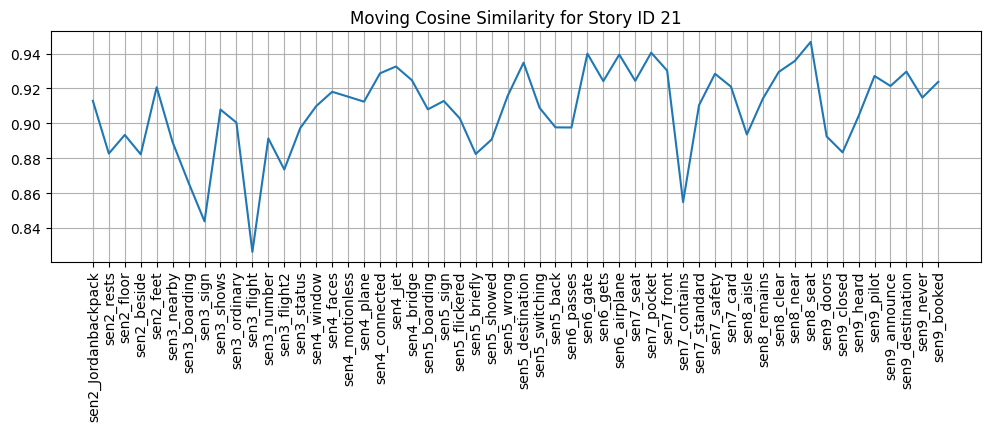

Story ID 21, sentence number of outlier at threshold 0.8934: [2, 3, 5, 7, 9]
Story ID 21, sentence number of outlier at threshold 0.8747: [3, 7]






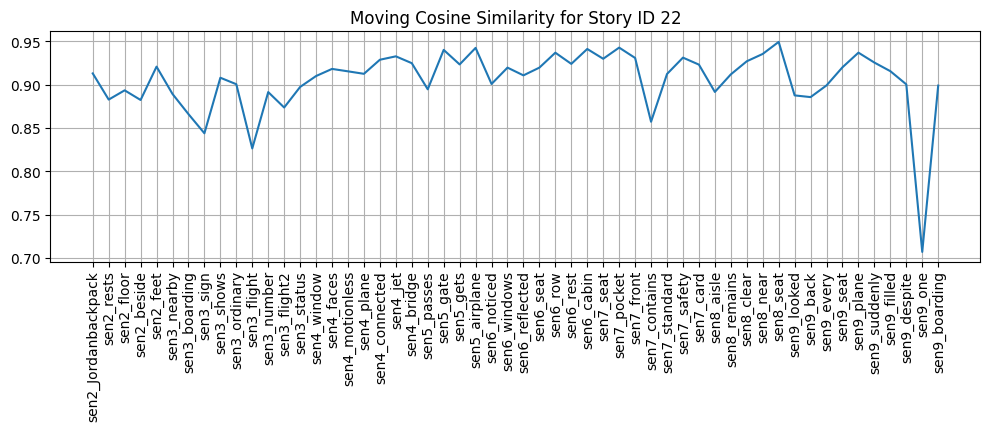

Story ID 22, sentence number of outlier at threshold 0.8937: [2, 3, 7, 8, 9]
Story ID 22, sentence number of outlier at threshold 0.8740: [3, 7, 9]
Story ID 22, sentence number of outlier at threshold 0.8543: [3, 9]






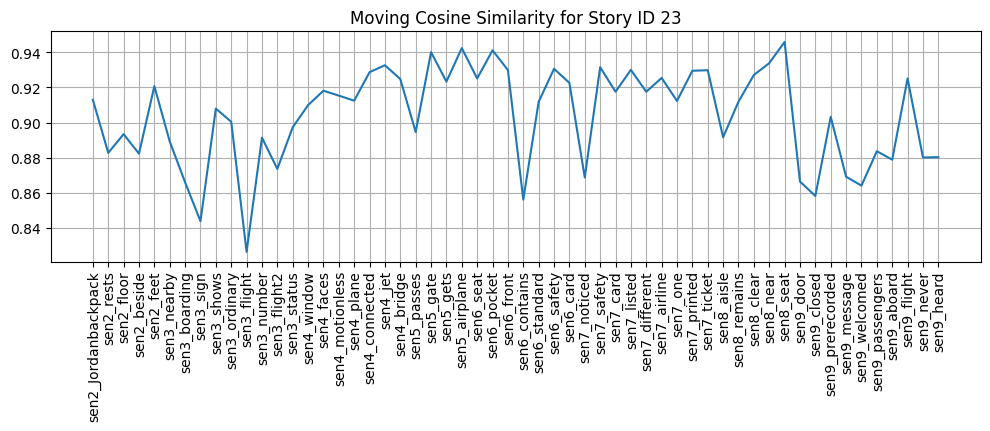

Story ID 23, sentence number of outlier at threshold 0.8826: [2, 3, 6, 7, 9]
Story ID 23, sentence number of outlier at threshold 0.8567: [3, 6]






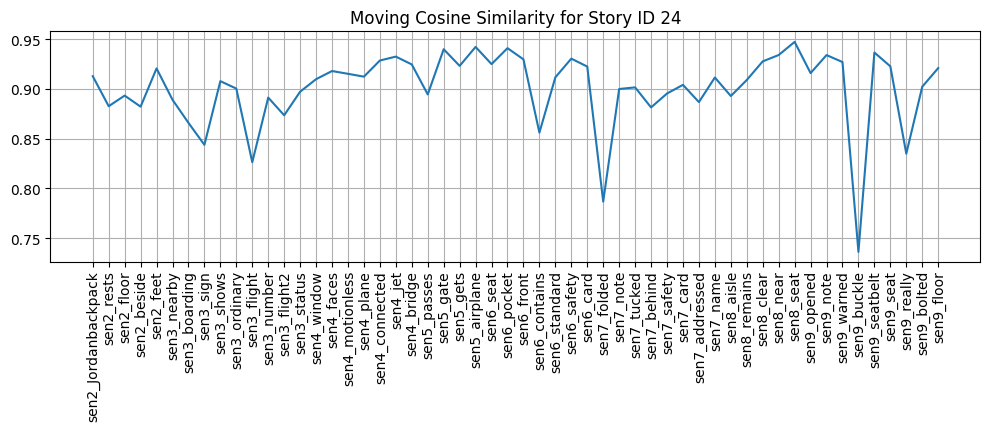

Story ID 24, sentence number of outlier at threshold 0.8918: [2, 3, 6, 7, 9]
Story ID 24, sentence number of outlier at threshold 0.8718: [3, 6, 7, 9]
Story ID 24, sentence number of outlier at threshold 0.8519: [3, 7, 9]
Story ID 24, sentence number of outlier at threshold 0.8320: [3, 7, 9]
Story ID 24, sentence number of outlier at threshold 0.8121: [7, 9]






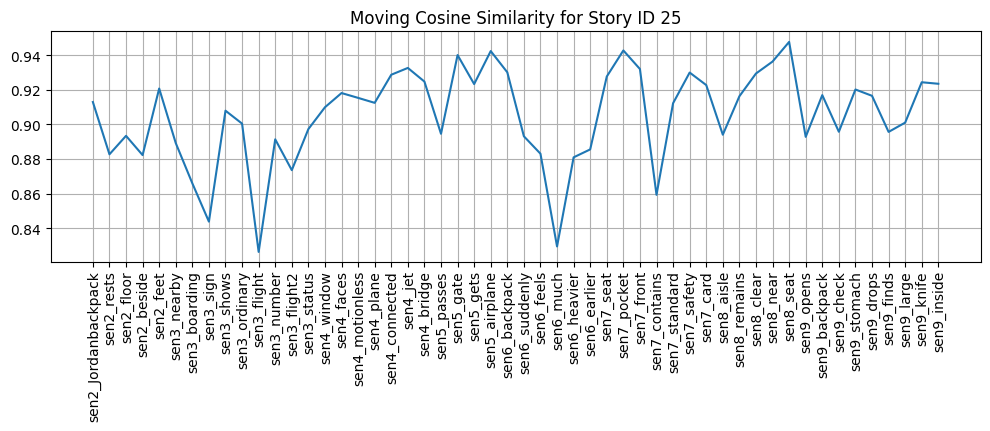

Story ID 25, sentence number of outlier at threshold 0.8924: [2, 3, 6, 7]
Story ID 25, sentence number of outlier at threshold 0.8732: [3, 6, 7]
Story ID 25, sentence number of outlier at threshold 0.8540: [3, 6]






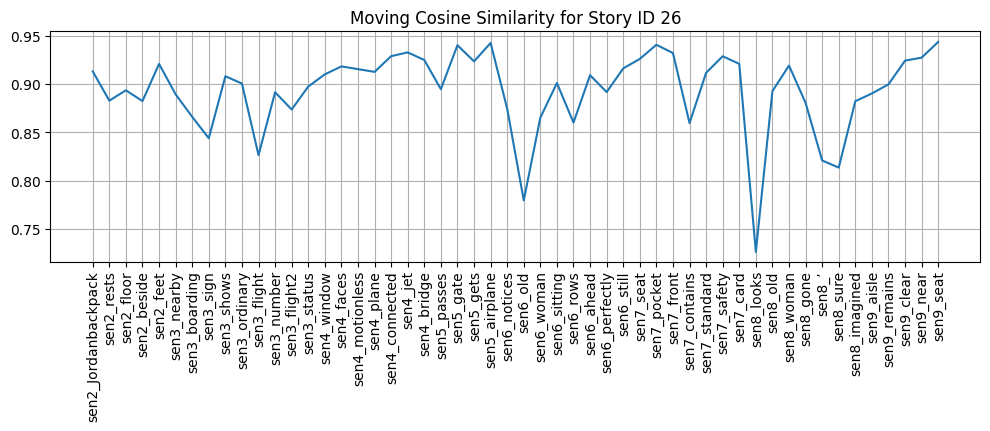

Story ID 26, sentence number of outlier at threshold 0.8817: [3, 6, 7, 8]
Story ID 26, sentence number of outlier at threshold 0.8578: [3, 6, 8]
Story ID 26, sentence number of outlier at threshold 0.8340: [3, 6, 8]
Story ID 26, sentence number of outlier at threshold 0.8102: [6, 8]






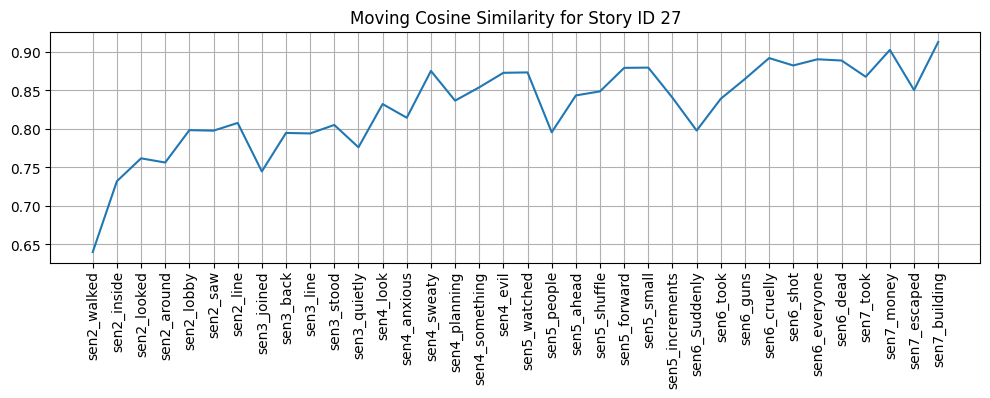

Story ID 27, sentence number of outlier at threshold 0.7971: [2, 3, 5]
Story ID 27, sentence number of outlier at threshold 0.7511: [2, 3]






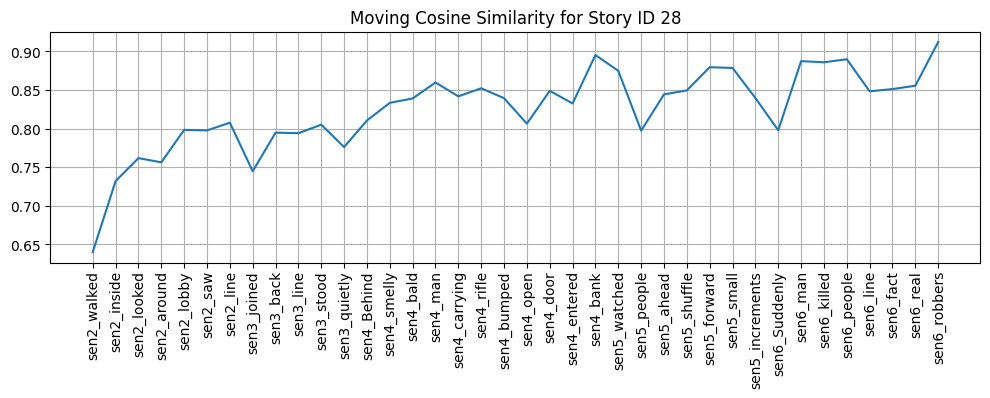

Story ID 28, sentence number of outlier at threshold 0.7977: [2, 3, 5]
Story ID 28, sentence number of outlier at threshold 0.7635: [2, 3]






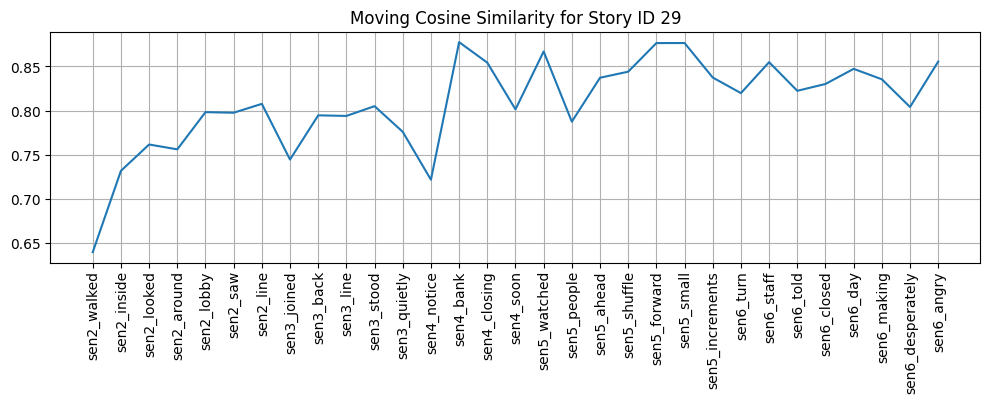

Story ID 29, sentence number of outlier at threshold 0.7908: [2, 3, 4, 5]
Story ID 29, sentence number of outlier at threshold 0.7578: [2, 3, 4]
Story ID 29, sentence number of outlier at threshold 0.7249: [2, 4]






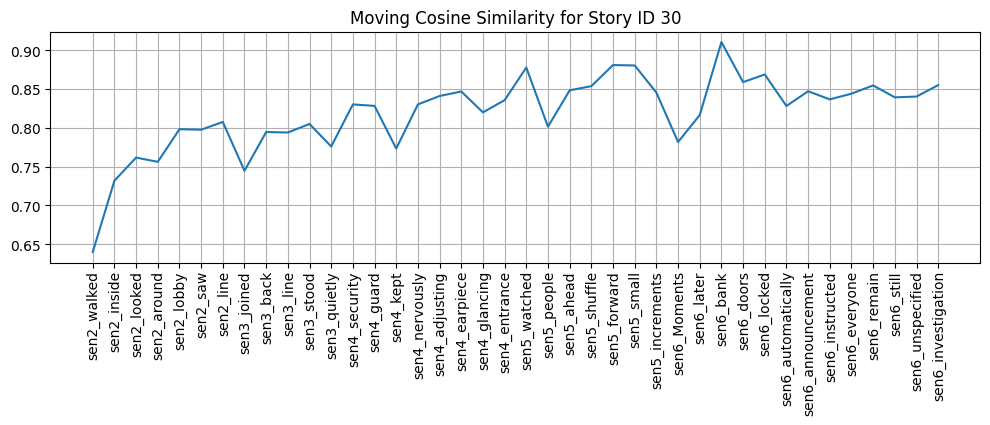

Story ID 30, sentence number of outlier at threshold 0.7969: [2, 3, 4, 6]
Story ID 30, sentence number of outlier at threshold 0.7665: [2, 3]






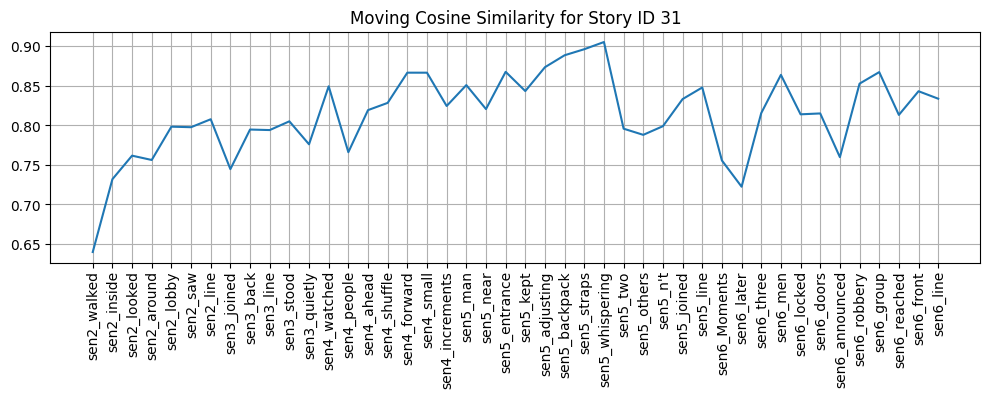

Story ID 31, sentence number of outlier at threshold 0.7925: [2, 3, 4, 5, 6]
Story ID 31, sentence number of outlier at threshold 0.7582: [2, 3, 6]
Story ID 31, sentence number of outlier at threshold 0.7239: [2, 6]






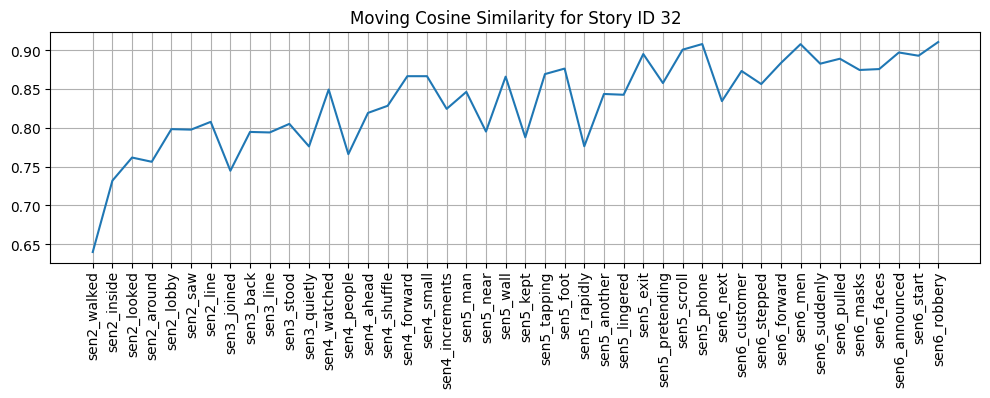

Story ID 32, sentence number of outlier at threshold 0.7951: [2, 3, 4, 5]
Story ID 32, sentence number of outlier at threshold 0.7466: [2, 3]






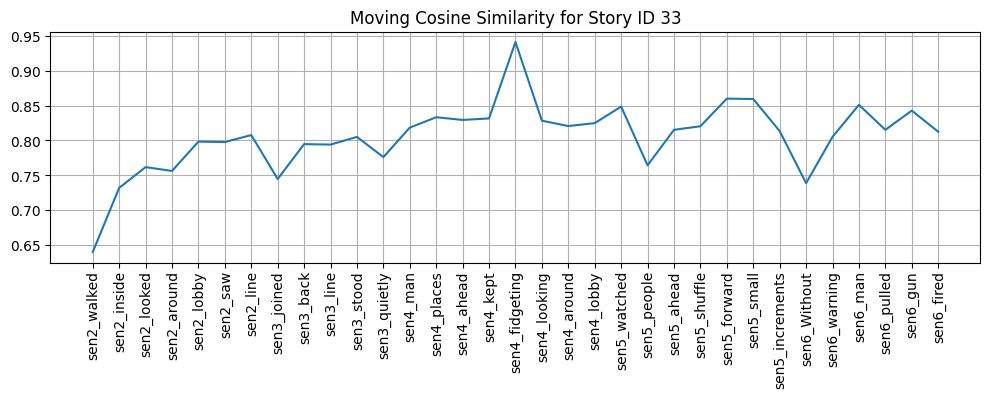

Story ID 33, sentence number of outlier at threshold 0.7940: [2, 3, 5, 6]
Story ID 33, sentence number of outlier at threshold 0.7728: [2, 3, 5, 6]
Story ID 33, sentence number of outlier at threshold 0.7516: [2, 3, 6]
Story ID 33, sentence number of outlier at threshold 0.7304: [2]






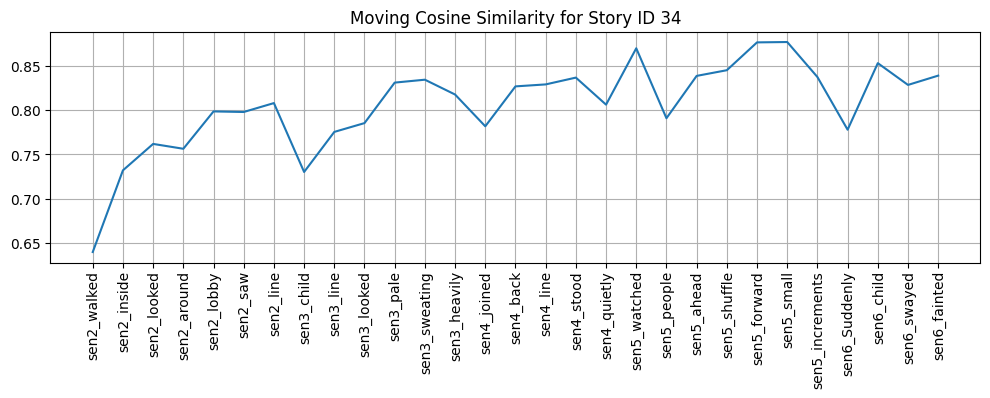

Story ID 34, sentence number of outlier at threshold 0.7815: [2, 3, 4, 6]
Story ID 34, sentence number of outlier at threshold 0.7483: [2, 3]






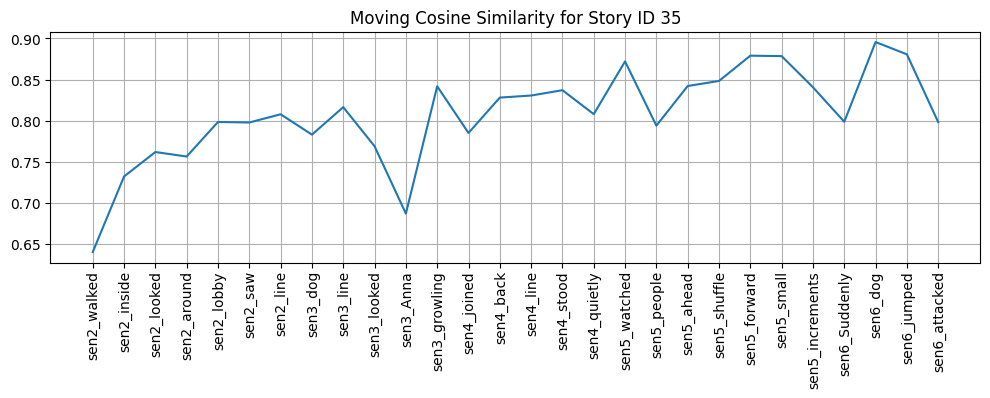

Story ID 35, sentence number of outlier at threshold 0.7844: [2, 3]





Stories processed: 36
Stories with M ≠ 0: 30 (83.33%)


,M,A,B,Note
0,0.305495,0.069128,0.847355,restaurant
1,0.301933,0.042881,0.862917,restaurant
2,0.267226,0.111324,0.690354,restaurant
3,0.299693,0.052203,0.846876,restaurant
4,0.289103,0.076319,0.790989,restaurant
5,0.000000,0.000000,0.000000,restaurant
6,0.202912,0.090600,0.518135,restaurant
7,0.000000,0.000000,0.000000,restaurant
8,0.286599,0.040279,0.819518,restaurant
9,0.202918,0.044538,0.564216,work routine


In [ ]:
## ModernBERT-large: 1024-dim hidden states
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "answerdotai/ModernBERT-large"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID).to(DEVICE).eval()

# concat all stories from III. Modified Stories
restaurant = restaurant_kyle + restaurant_cindy + restaurant_naharin
work_routine = work_routine_kyle + work_routine_cindy + work_routine_naharin
airport = airport_kyle + airport_cindy + airport_naharin
bank = bank_kyle + bank_cindy + bank_naharin
all_story = restaurant + work_routine + airport + bank

# single_story is for evaluating just one story
# overwrite single_story with your own story
single_story = ["""Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
Behind them, a smelly, bald man carrying a rifle bumped open the door and entered the bank.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the man killed all the people in line because they are in fact the real robbers."""]

## HYPERPARAMS
story_set = all_story
# story_set = single_story
plot_mcs_yes = True # moving cosine similarity (mcs) graph
print_outlier_yes = True  # value of threshold of outlier selection algorithm
calculating_mcs_with_skipped_tokens = True  # whether include the first sentence when calculating mcs

result = story_set_run_ModernBERT(story_set)


In [ ]:
## Analysis Phase I
df = pd.DataFrame(result, columns=["M","A","B","Note"])
df_restaurant = df[df["Note"]=="restaurant"]
df_work_routine = df[df["Note"]=="work routine"]
df_airport = df[df["Note"]=="airport"]
df_bank = df[df["Note"]=="bank"]

# display(df_restaurant)
# display(df_work_routine)
# display(df_airport)
# display(df_bank)

print(f"\nTotal Processed Story: {len(df)}\n")

# ratio of M ≠ 0 stories (M≠0 stories / total stories)
ratio_restaurant = (df_restaurant["M"] > 0).sum() / len(df_restaurant)
ratio_work_routine = (df_work_routine["M"] > 0).sum() / len(df_work_routine)
ratio_airport = (df_airport["M"] > 0).sum() / len(df_airport)
ratio_bank = (df_bank["M"] > 0).sum() / len(df_bank)
ratio_overall = (df["M"] > 0).sum() / len(df)
print(f'M ≠ 0 Ratio of Restaurant Story: {ratio_restaurant:.0%} ({(df_restaurant["M"]>0).sum()}/{len(df_restaurant)})')
print(f'M ≠ 0 Ratio of Work Routine Story: {ratio_work_routine:.0%} ({(df_work_routine["M"]>0).sum()}/{len(df_work_routine)})')
print(f'M ≠ 0 Ratio of Airport Story: {ratio_airport:.0%} ({(df_airport["M"]>0).sum()}/{len(df_airport)})')
print(f'M ≠ 0 Ratio of Bank Story: {ratio_bank:.0%} ({(df_bank["M"]>0).sum()}/{len(df_bank)})')
print(f'>> Overall Ratio: {ratio_overall:.0%} ({(df["M"]>0).sum()}/{len(df)})\n')

# mean M value of M ≠ 0 stories
M_restaurant = df_restaurant[df_restaurant["M"] > 0]["M"].mean()
M_work_routine = df_work_routine[df_work_routine["M"] > 0]["M"].mean()
M_airport = df_airport[df_airport["M"] > 0]["M"].mean()
M_bank = df_bank[df_bank["M"] > 0]["M"].mean()
M_overall = df[df["M"] > 0]["M"].mean()
print(f'Mean M Value of Restaurant Story: {M_restaurant:.2f}')
print(f'Mean M Value of Work Routine Story: {M_work_routine:.2f}')
print(f'Mean M Value of Airport Story: {M_airport:.2f}')
print(f'Mean M Value of Bank Story: {M_bank:.2f}')
print(f'>> Overall Mean M Value: {M_overall:.2f}')




Total Processed Story: 36

M ≠ 0 Ratio of Restaurant Story: 78% (7/9)
M ≠ 0 Ratio of Work Routine Story: 67% (6/9)
M ≠ 0 Ratio of Airport Story: 100% (9/9)
M ≠ 0 Ratio of Bank Story: 89% (8/9)
>> Overall Ratio: 83% (30/36)

Mean M Value of Restaurant Story: 0.28
Mean M Value of Work Routine Story: 0.28
Mean M Value of Airport Story: 0.29
Mean M Value of Bank Story: 0.25
>> Overall Mean M Value: 0.27


## Archive

In [ ]:
## Kyle's Stroies (3 versions for each story)
"""
1. Restaurant Story

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
The waiter was nervous when he put a mini GPS tracker into their food.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
Through the GPS traker, the waiter lurked into their home and killed them in their sleep.

--------------------------------------------------------------------------------

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
They did not notice the shattered glasses on the floor.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
On the road, they had a flat tire because one of the tire was pierced by the shattered glass.

--------------------------------------------------------------------------------

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
The waiter secretly added an unknown powder to their food without being noticed.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
On their way home, the powder began to take effect, swapping their souls.

================================================================================
2. Work Routine Story

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A man passed by Ethan and reccklessly bumped his shoulder.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Only until then, Ethan realized his watch was stolen by the man who bumped him.

--------------------------------------------------------------------------------

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
She did not watch the road and was tripped by a huge pothole, causing her knee to bleed.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Tina's wound was infected by an alien virus and she turned into a intimidating zombie.

--------------------------------------------------------------------------------

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A little puppy followed them along without being noticed.
They arrived at the company and started their usual routine.
When they got off work, they saw the puppy waiting patiently at the company entrance.
They decided to take in the puppy as their pet, and they lived happily ever after.

================================================================================
3. Airport Story

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
A weird creature lurked into the seat pocket quietly.
The aisle remains clear near Jordan's seat.
After Jordan fell asleep, a poisonous snake came out from the seat pocket and bit Jordan in the leg, causing Jordan to die in agonizingly pain.

--------------------------------------------------------------------------------

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A tiny but deadly air cannon was hidden inside his backpack.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
Jordan used the air cannon to hijack the plane and made everyone give in their airplane meals.

--------------------------------------------------------------------------------

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
He did not notice a man quietly approaching him.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
The man sneaked up to Jordan, tagging him as the next tagger in the tagging game.


================================================================================
4. Bank Story

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They look anxious and sweaty because they are planning something evil.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, they took out guns and cruelly shot everyone dead.
They took all the money and escaped the building.

--------------------------------------------------------------------------------

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
Behind them, a smelly, bald man carrying a rifle bumped open the door and entered the bank.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the man killed all the people in line because they are in fact the real robbers.

--------------------------------------------------------------------------------

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They did not notice that the bank was closing soon.
They watched the people ahead of them shuffle forward in small increments.
When it was their turn, the staff told them they were closed for the day, making them desperately angry.

"""

In [ ]:
## Cindy's stories:
"""
1. Restaurant Story

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Judy noticed a small scratch on the car door that hadn’t been there earlier.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
When they arrived home, their garage door was already open even though they had closed it that morning.

--------------------------------------------------------------------------------

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
A faint smell of burning rubber drifted into the restaurant every time the door opened.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
Halfway home, smoke suddenly rose from under the hood as their car broke down in the same spot where Sam had parked earlier.

--------------------------------------------------------------------------------

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Judy thought she saw someone duck behind their parked car as they walked toward the entrance.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
When they got home, muddy footprints led from their driveway to their back door.

================================================================================
2. Work Routine Story

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A delivery truck slowly rolled beside them for several blocks without ever passing.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Minutes after they entered the building, the same delivery truck pulled up and a man stepped out asking specifically for Ethan.

--------------------------------------------------------------------------------

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A strange buzzing announcement echoed faintly from a nearby street speaker, but neither of them could understand the words.
They arrived at the company and started their usual routine.
Seconds after they walked inside, all phones in the building lit up with an emergency alert instructing everyone to evacuate immediately.

--------------------------------------------------------------------------------

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
A bus driver stared at Ethan through the window as it passed, as if recognizing him.
They arrived at the company and started their usual routine.
Hours later, Ethan saw the same bus driver waiting at the lobby desk asking for him by name.

================================================================================
3. Airport Story

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
The boarding sign flickered once and briefly showed the wrong destination before switching back.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
As the doors closed, Jordan heard the pilot announce a destination he had never booked.

--------------------------------------------------------------------------------

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
Jordan noticed the windows reflected only his seat row, not the rest of the cabin.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
When Jordan looked back, every other seat on the plane was suddenly filled despite no one boarding with him.

--------------------------------------------------------------------------------

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
Jordan noticed that the safety card listed a different airline than the one printed on his ticket.
The aisle remains clear near Jordan's seat.
Once the door closed, a prerecorded message welcomed passengers aboard a flight Jordan had never heard of.

================================================================================
4. Bank Story

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
The security guard kept nervously adjusting his earpiece and glancing at the entrance.
They watched the people ahead of them shuffle forward in small increments.
Moments later, the bank doors locked automatically and an announcement instructed everyone to remain still for an unspecified investigation.

--------------------------------------------------------------------------------

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
A man near the entrance kept adjusting his backpack straps and whispering to two others who hadn’t joined the line.
Moments later, the three men locked the doors and announced a robbery just as Anna’s group reached the front of the line.

--------------------------------------------------------------------------------

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
A man near the wall kept tapping his foot rapidly while another lingered by the exit pretending to scroll his phone.
As the next customer stepped forward, both men suddenly pulled masks over their faces and announced the start of a robbery.

"""

In [ ]:
## Naharin's Story

"""
1. Restaurant Story

Sam and Judy went out for dinner at their favorite restaurant.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
They noticed that the waiter was sweating profusely, constantly glancing around the dining room.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
As they stepped outside, they heard the manager shout, “Somebody call securit, that man wasn’t our waiter!”

--------------------------------------------------------------------------------

Sam and Judy went out for dinner at their favorite restaurant.
On their way out the door, Sam noticed their porch light flicker twice, though the power in the house was fine.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
As they stood to leave the restaurant, Judy realized her phone had recorded a call she never made from a number matching their home address.
They paid their tab, left a tip for the waiter, and drove back home.

--------------------------------------------------------------------------------

Sam and Judy went out for dinner at their favorite restaurant.
Judy had grown up never knowing who her biological father was.
While driving to the restaurant, Judy's favorite song played on the radio.
Sam found a parking space at the very front of the restaurant.
Sam and Judy were seated immediately and ordered their favorite food to the waiter standing next to them.
Sam's favorite song played on the radio while they waited for their food.
Sam and Judy enjoyed their meal.
They paid their tab, left a tip for the waiter, and drove back home.
Later that night, Judy received a text from an unknown number saying it was the waiter from the restaurant and he was her father.

================================================================================
2. Work Routine Story

Ethan and Tina began their morning commute together along the sidewalk.
Tina noticed a man in a company jacket quickly take a photo of her.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
Tina caught up and crossed the street after checking for traffic.
At the company entrance, the same man approached Tina and asked if she wanted to model for his agency.
They arrived at the company and started their usual routine.

--------------------------------------------------------------------------------

Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster and looked at the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A man walking his dog smiled at Ethan and said, “See you inside,” even though Ethan didn’t know him.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Only then did Ethan realize the man with the dog was his new boss.

--------------------------------------------------------------------------------
Ethan and Tina began their morning commute together along the sidewalk.
Ethan walked faster, watching the lines of cars moving down the road.
Tina slowed down to use her phone and fell behind.
Ethan kept a steady pace and glanced at his watch.
A delivery truck drove past and a small box tumbled out onto the sidewalk at Ethan’s feet, so he picked it up.
Tina caught up and crossed the street after checking for traffic.
They arrived at the company and started their usual routine.
Only then did Ethan notice the box had his name on it and the company logo.

================================================================================
3. Airport Story

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number with an flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
The seat pocket in front of Jordan contains the standard safety card.
A folded note was tucked behind the safety card, addressed to Jordan by name.
The aisle remains clear near Jordan's seat.
When Jordan opened the note, it warned him not to buckle his seatbelt because the seat was not really bolted to the floor.

--------------------------------------------------------------------------------
Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number and a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
His backpack suddenly feels much heavier than it did earlier.
The seat pocket in front of Jordan contains the standard safety card.
The aisle remains clear near Jordan's seat.
Jordan opens his backpack to check, and his stomach drops when he finds a large knife inside.

--------------------------------------------------------------------------------

Jordan sits in the airport gate area among rows of scattered chairs.
Jordan's backpack rests on the floor beside his feet.
A nearby boarding sign shows an ordinary flight number and a flight status.
Through the window, Jordan faces a motionless plane connected to the jet bridge.
Jordan passes through the gate and gets on the airplane.
He notices an old woman sitting a few rows ahead, perfectly still.
The seat pocket in front of Jordan contains the standard safety card.
When he looks up again, the old woman is gone, and Jordan isn’t sure if he imagined her.
The aisle remains clear near Jordan's seat.


================================================================================
4. Bank Story

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
They joined the back of the line and stood quietly.
A man a few places ahead of them kept fidgeting and looking around the lobby.
They watched the people ahead of them shuffle forward in small increments.
Without warning, the man pulled out a gun and fired.

--------------------------------------------------------------------------------

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
A child in the line looked pale and was sweating heavily.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the child swayed and fainted.

--------------------------------------------------------------------------------

Anna walked to the bank with Mark and Julia.
They walked inside, looked around the lobby, and saw a line.
A dog was in the line and looked at Anna, growling.
They joined the back of the line and stood quietly.
They watched the people ahead of them shuffle forward in small increments.
Suddenly, the dog jumped and attacked Anna.

"""

In [ ]:
## Outdated Functions

# story_preprocess without ##
# def story_preprocess(story):
#   story_split = sentence_split(story) # split the story (one string) to a list of sentences
#   sentences = []


#   person_name = {"Beep"}  # put Beep in the set manually because spacy failed to recognize this name
#   # person_name = set()
#   for sentence in story_split:
#     sentence_processed, person_name = rmv_name_and_stopwd(sentence, person_name)
#     sentences.append(sentence_processed)

#   # tokenization
#   encoded_input = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True, add_special_tokens=True).to(DEVICE)
#   input_ids = encoded_input['input_ids']
#   attention_mask = encoded_input['attention_mask']

#   # run BERT
#   with torch.no_grad():
#       output = model(**encoded_input)

#   last_hidden_state = output.last_hidden_state   # last_hidden_state has a size = (batch_size, sequence_length, hidden_size)
#                             # For a single sentence, batch_size will be 1. (I still get 1 with multiple sentence but I assume it wouldn't matter much)
#                             # sequence_length corresponds to the number of tokens (including special tokens)
#                             # hidden_size is the dimensionality of the embeddings (768 for bert-base-uncased, 1024 for bert-large-uncased).

#   tokens_cleaned = []
#   word_embeddings_cleaned = []
#   each_word_sent_id = []
#   first_sentence_word_count = 0

#   for i, sentence in enumerate(sentences):
#       sentence_embeddings = last_hidden_state[i]
#       tokens = tokenizer.convert_ids_to_tokens(input_ids[i])
#       word_ids = encoded_input.word_ids(i)


#       for j in range(len(tokens)):

#         if attention_mask[i][j] == 1 and input_ids[i][j] != 101 and input_ids[i][j] != 102: # 101 is [CLS] and 102 is [SEP]
#             token_str = "sen" + str(i+1) + "_" + tokens[j]
#             tokens_cleaned.append(token_str)
#             word_embeddings_cleaned.append(sentence_embeddings[j])
#             # print(word_embeddings_cleaned)
#             if i == 0:
#                 first_sentence_word_count += 1

#   return tokens_cleaned, word_embeddings_cleaned, each_word_sent_id, first_sentence_word_count

# def words_and_sentence_ids(text: str):
#     """Return flat word list and per-word sentence id (0,1,2,...) using whitespace tokenization."""
#     sents = sentence_split(text)
#     words = []
#     sent_ids = []
#     for sid, s in enumerate(sents):
#         ws = s.split()  # split on space or even multiple spaces
#         print(f'Sentence #{sid+1}:', s)   # disabled the prints due to long output
#         print(f'Sentence #{sid+1}: word count {len(ws)}')
#         # print(f'Sentence #{sid+1} as a list: {ws}')
#         words.extend(ws)
#         sent_ids.extend([sid]*len(ws))
#     # print('words:', words)
#     # print('sent_ids:', sent_ids)
#     return words, sent_ids, sents

# def select_outliers(series, series_sent_ids):

#     x = np.asarray(series, dtype=float)
#     med = np.median(x)
#     mad = np.median(np.abs(x - med)) + 1e-8
#     z = (x - med) / mad

#     # progressively lower the (one-sided, lower-tail) threshold
#     for thr in [-0.25, -0.50, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -3.0, -3.5, -4.0, -4.5, -5.0, -5.5, -6.0]:
#         idxs = np.where(z <= thr)[0].tolist()
#         if len(idxs) < 2:
#             continue
#         # print(idxs)
#         sents = {series_sent_ids[j] for j in idxs}
#         if len(sents) == 2:  # or len(sents) == 3
#             return idxs
#     return None

# def per_word_contextual_embeddings(text: str):
#     if not text.strip():
#         return [], []
#     enc = tok(text, return_offsets_mapping=True, return_tensors="pt", add_special_tokens=True)
#     test_tokens = tok.convert_ids_to_tokens(enc['input_ids'][0])  # for checking sentence segmentation
#     print(test_tokens)
#     word_ids = enc.word_ids()

#     inputs = {k: v.to(DEVICE) for k, v in enc.items() if k in ("input_ids", "attention_mask", "token_type_ids")}

#     with torch.inference_mode():
#         out = mdl(**inputs)
#         token_h = out.last_hidden_state.squeeze(0).detach().cpu()  # (T, H) # why send to cpu?

#     words = text.split()
#     buckets = {}
#     for tidx, wid in enumerate(word_ids):
#         if wid is None:
#             continue
#         buckets.setdefault(wid, []).append(token_h[tidx])

#     word_vecs = []
#     for wid in range(len(words)):
#         if wid in buckets:
#             word_vecs.append(torch.stack(buckets[wid], dim=0).mean(dim=0))
#         else:
#             word_vecs.append(torch.zeros(token_h.shape[-1]))
#     return word_vecs


# def moving_cosine_series(word_vecs, start_idx: int):
#     """For i>=start_idx: cos(w_i, mean(w_0..w_{i-1}))."""
#     if len(word_vecs) <= start_idx:
#         return []
#     running_sum = None
#     series = []
#     for i, v in enumerate(word_vecs):
#         if running_sum is None:
#             running_sum = v.clone()
#             continue

#         if i >= start_idx:
#             mean_prev = running_sum / i
#             cs = F.cosine_similarity(v, mean_prev, dim=0).item()
#             series.append(cs)
#         # print('running:',running_sum)
#         # print('v:', v)
#         running_sum = running_sum + v
#     return series

# def compute_M_for_text(text: str, plot: bool):
#     """
#       - A = 1 - cos(mean(all), mean(outliers))
#       - B = avg_i cos(o_i, mean(O \ {i}))
#       - M = (A + |B|)/3
#     If fewer than 2 sentences after the first, return M=0.
#     """
#     # Build word list + sentence ids (whitespace-based)
#     words, sent_ids, sents = words_and_sentence_ids(text)
#     # print(f'len(sents): {len(sents)}')
#     # print(f'len(words): {len(words)}')

#     if len(sents) < 2 or len(words) < 2:
#         print('error1')
#         return 0.0, 0.0, 0.0

#     flat_text = " ".join(words)
#     vecs = per_word_contextual_embeddings(flat_text)
#     if len(vecs) != len(words) or len(vecs) < 2:
#         print('error2')
#         return 0.0, 0.0, 0.0

#     # Start after sentence 1
#     first_sentence_word_count = sum(1 for sid in sent_ids if sid == 0)
#     start_idx = first_sentence_word_count
#     # print('start_idx:', start_idx)
#     series = moving_cosine_series(vecs, start_idx)

#     if not series:
#         print('error3')
#         return 0.0, 0.0, 0.0

#     series_sent_ids = [sent_ids[start_idx + j] for j in range(len(series))]
#     unique_after_first = sorted(set(series_sent_ids))
#     if len(unique_after_first) < 2:
#         print('error4')
#         return 0.0, 0.0, 0.0

#     if plot:
#         # print('series len:', len(series))
#         # print('words len:', len(words))
#         plot_mcs(series, words, sent_ids, start_idx)

#     # Compute per-sentence mean of series and pick the two lowest-mean sentences
#     outlier_positions = select_outliers(series, series_sent_ids)
#     if not outlier_positions:
#         print('error5: M=0 when two sentences are not found')
#         return 0.0, 0.0, 0.0  # per paper, M=0 if we can't find exactly two sentences

#     # Map back to original word indices
#     outlier_word_idxs = [start_idx + j for j in outlier_positions]
#     O = [vecs[i] for i in outlier_word_idxs]
#     # A = 1 - cos(mean(all), mean(O))
#     all_mean = torch.stack(vecs, dim=0).mean(dim=0)
#     out_mean = torch.stack(O, dim=0).mean(dim=0)
#     # print(f'all_mean: {all_mean}')
#     # print(f'out_mean: {out_mean}')
#     A = (1.0 - F.cosine_similarity(all_mean, out_mean, dim=0).item())

#     # B = avg over i in O of cos(o_i, mean(O \ {i}))
#     if len(O) == 1:
#         B = 0.0
#     else:
#         Ostack = torch.stack(O, dim=0)
#         sims = []
#         for i in range(len(O)):
#             others = torch.cat([Ostack[:i], Ostack[i+1:]], dim=0).mean(dim=0)
#             sims.append(F.cosine_similarity(Ostack[i], others, dim=0).item())
#         B = float(np.mean(sims))

#     M = (A + abs(B)) / 3.0
#     return float(M), float(A), float(B)

# outlier selection for selecting M=0 raw stories
# def select_outliers(series, series_sent_ids):
#     mcs = np.asarray(series, dtype=float)
#     Q1 = np.percentile(mcs, 25)
#     Q3 = np.percentile(mcs, 75)
#     IQR = Q3 - Q1

#     if np.std(mcs) <= 0.06:
#       # print('compact enough')
#       for i in range (0,100,1):
#         thr = Q1 - IQR*i*0.01
#         idxs = np.where(mcs <= thr)[0].tolist()
#         sents = {series_sent_ids[j] for j in idxs}

#         if len(sents) >= 3:
#           continue
#         if len(sents) == 2:
#           return idxs

#       return None
#     else:
#       # print('loose')
#       return [5,6]

# def no_quotations(text: str) -> bool:
#   QUOTE_PATTERN = re.compile(r'[“”"]')  #filter quotation marks
#   if not isinstance(text, str):
#       return False
#   return QUOTE_PATTERN.search(text) is None


In [ ]:
## Story Extraction (not using)
## trying to filter stories we need that has no quotation marks and M=0

# hyperparams
# MAX_STORIES = 2000
# PLOT = True #too long if set 2 true
# calculating_mcs_with_skipped_tokens = True


# results_m0 = []      #M == 0 and no_dialogue == True
# processed = 0
# kept_no_dialogue = 0
# found_m0 = 0


# for idx, ex in enumerate(ds):
#     if processed >= MAX_STORIES or found_m0 == 9:
#         break

#     story = ex.get("text") or ex.get("story") or ""

#     if not isinstance(story, str) or not story.strip():
#         # skip empty
#         continue

#     processed += 1

#     if not no_quotations(story):
#         continue
#     kept_no_dialogue += 1

#     try:

#         tokens, word_embeddings, each_word_sent_id, first_sentence_word_count = story_preprocess(story)
#         moving_cosine_similarity = mcs(word_embeddings, first_sentence_word_count, calculating_mcs_with_skipped_tokens) # the returned mcs is skipped (if calculating_mcs_with_skipped_tokens = True)
#         M, A, B = compute_M(word_embeddings, moving_cosine_similarity, first_sentence_word_count, each_word_sent_id)
#         print(story)
#         if M == 0:
#             results_m0.append((idx, M, A, B, story, True))
#             found_m0 += 1
#             if PLOT:
#                 plot_mcs(moving_cosine_similarity, tokens[first_sentence_word_count:], each_word_sent_id[first_sentence_word_count:])

#     except Exception as e:
#         print(f"[warn] error on story idx={idx}: {e}")



# df_m0 = pd.DataFrame(
#     results_m0,
#     columns=["idx", "M", "A", "B", "text", "no_dialogue"]
# )
# print(f"No-quote stories kept:     {kept_no_dialogue}")
# print(f"No-quote with M = 0:       {found_m0}")



# print("\nExamples (no-quote & M=0):")
# # display(df_m0.head(5)[["idx","M","A","B","text"]])
# display(df_m0)
# for i, row in enumerate(df_m0.head(9).itertuples(), start=1):
#     print(f"\nStory {i}: (idx={row.idx}, M={row.M})")
#     print(row.text)
#     print("-" * 80)

In [ ]:
## Hints/Twists (Experiment)

# !pip install --quiet blingfire pandas numpy nltk

# import re, random
# import numpy as np
# import pandas as pd
# from blingfire import text_to_sentences
# import nltk


# nltk.download("averaged_perceptron_tagger", quiet=True)
# nltk.download("averaged_perceptron_tagger_eng", quiet=True)


# def sent_tokenize(text: str):
#     if not text:
#         return []
#     sents = text_to_sentences(str(text)).split("\n")
#     sents = [s.strip() for s in sents if s and s.strip()]
#     return sents

# def join_sents(sents):
#     text = " ".join(sents)
#     text = re.sub(r"\s+([?.!,;:])", r"\1", text)
#     text = re.sub(r"\s{2,}", " ", text)
#     return text.strip()

# def is_dialog_sentence(s: str):
#     s = s.strip()
#     if not s: return False
#     return s.startswith(("\"", "“", "‘", "'")) or s.count('"') + s.count('“') + s.count('”') >= 2

# def nearest_non_dialog_index(sents, idx):
#     n = len(sents)
#     if n == 0: return 0
#     if idx >= n: idx = n-1
#     if not is_dialog_sentence(sents[idx]):
#         return idx
#     # search outward
#     for d in range(1, max(idx, n-idx)+1):
#         left = idx - d
#         right = idx + d
#         if 0 <= left and not is_dialog_sentence(sents[left]): return left
#         if right < n and not is_dialog_sentence(sents[right]): return right
#     return min(idx, n-1)

# PRONOUNY = {
#     'someone','somebody','something','anyone','anybody','anything',
#     'everyone','everybody','everything','noone','nobody','nothing',
#     'thing','stuff','time','day','way','people','person','man','woman','guy'
# }
# STOP_LITE = {
#     'the','a','an','and','but','or','nor','so','because','as','of','to','in','on','for','with',
#     'from','at','by','into','over','after','before','between','through','during','without','about',
#     'above','below','up','down','out','off','again','further'
# }

# def detect_tense(text):
#     t = str(text).lower()
#     past = len(re.findall(r"\b(was|were|did|had)\b", t))
#     pres = len(re.findall(r"\b(is|are|does|has)\b", t))
#     return "past" if past >= pres else "present"

# def detect_pov(text):
#     t = str(text).lower()
#     c1 = len(re.findall(r"\b(i|me|my|mine|we|us|our|ours)\b", t))
#     c2 = len(re.findall(r"\byou|your|yours\b", t))
#     if c1 > c2 and c1 >= 2: return "first"
#     if c2 > c1 and c2 >= 2: return "second"
#     return "third"

# def tokens_for_pos(text):
#     return re.findall(r"[A-Za-z][A-Za-z'-]{1,}", str(text))

# def looks_like_entity(token, is_sentence_start=False):

#     return (not is_sentence_start) and token[:1].isupper()

# def rank_common_nouns(text, sents, top_k=8):
#     """
#     Pick salient concrete nouns:
#     - POS-only NN/NNS (no proper nouns NNP/NNPS, no pronouns)
#     - filter stopwords, generic/pronouny words
#     - avoid named entities by filtering capitalized tokens not at sentence start
#     - rank by frequency and early-mention boost (good for hints)
#     """
#     tokens = []
#     for s in sents:
#         words = re.findall(r"[A-Za-z][A-Za-z'-]{1,}", s)
#         for i, w in enumerate(words):
#             tokens.append((w, i == 0))
#     if not tokens:
#         return ["room","door","night","voice","letter","key"]

#     just_tokens = [w for w,_ in tokens]
#     tagged = nltk.pos_tag(just_tokens)

#     freq = {}
#     first_pos = {}
#     for idx, ((w, start_flag), (_, pos)) in enumerate(zip(tokens, tagged)):
#         wl = w.lower()
#         if pos not in ("NN","NNS"):
#             continue
#         if wl in STOP_LITE or wl in PRONOUNY:
#             continue
#         if not wl.isalpha():
#             continue
#         if looks_like_entity(w, is_sentence_start=start_flag):
#             continue

#         freq[wl] = freq.get(wl, 0) + 1
#         first_pos.setdefault(wl, idx)

#     if not freq:
#         return ["room","door","night","voice","letter","key"]


#     max_idx = max(first_pos.values()) or 1
#     scores = {w: (freq[w] + 0.5*(1 - first_pos[w]/max_idx)) for w in freq}
#     ranked = sorted(scores, key=lambda w: (-scores[w], w))
#     return ranked[:top_k]


# def needs_an(word):
#     return re.match(r"^[aeiouAEIOU]", word) is not None

# def det_phrase(noun):

#     return f"the {noun}"

# def pluralize_if_needed(noun):

#     return noun


# def make_hint(theme_words, tense="past", pov="third", rng=None):
#     rng = rng or random
#     w = pluralize_if_needed(rng.choice(theme_words))
#     wdet = det_phrase(w)
#     if tense == "past":
#         base = [
#             f"Earlier, there was a small detail about {wdet} that didn't sit right.",
#             f"Before long, a quiet remark about {wdet} was easy to overlook.",
#             f"At the time, {wdet} seemed ordinary, but something felt off.",
#             f"No one noticed {wdet} then, tucked slightly out of place."
#         ]
#     else:
#         base = [
#             f"At first, something about {wdet} doesn’t add up.",
#             f"There’s a quiet remark about {wdet} that’s easy to overlook.",
#             f"{wdet.capitalize()} looks ordinary, but something feels off.",
#             f"Nobody notices {wdet}, just slightly out of place."
#         ]

#     if pov == "first":
#         base += [f"I should have paid more attention to {wdet}."]
#     elif pov == "second":
#         base += [f"You might overlook {wdet}, but it matters."]
#     return rng.choice(base)

# def make_twist(theme_words, tense="past", pov="third", rng=None):
#     rng = rng or random
#     w = pluralize_if_needed(rng.choice(theme_words))
#     wdet = det_phrase(w)
#     if tense == "past":
#         base = [
#             f"Only later did it become clear: {wdet} was never what they thought.",
#             f"In the end, {wdet} belonged to someone else entirely.",
#             f"Then the truth snapped into place—{wdet} had been the misdirection.",
#             f"It turned out {wdet} was missing for a reason no one would admit."
#         ]
#     else:
#         base = [
#             f"Only now is it clear: {wdet} isn’t what they think.",
#             f"In the end, {wdet} belongs to someone else entirely.",
#             f"The truth snaps into place—{wdet} is the misdirection.",
#             f"{wdet.capitalize()} is missing for a reason no one will admit."
#         ]
#     if pov == "first":
#         base += [f"I finally see it now—{wdet} changes everything."]
#     elif pov == "second":
#         base += [f"Now you can see it—{wdet} was pointing the other way."]
#     return rng.choice(base)

# def make_nonsense(theme_words, rng=None):
#     rng = rng or random
#     return rng.choice([
#         "The staircase tasted like Thursday, humming a square circle.",
#         "A pocket of silence barked politely at the wallpaper.",
#         "Gravity took a coffee break while the windows remembered soup.",
#         "The corridor wore pajamas and spoke fluent static."
#     ])

# def make_joke(theme_words, rng=None):
#     rng = rng or random
#     w = rng.choice(theme_words)
#     wdet = det_phrase(w)
#     return rng.choice([
#         f"Someone called it {wdet}, which was fair—if {w} secretly meant 'mild chaos.'",
#         f"{wdet.capitalize()} came with instructions: Step 1) Panic. Step 2) Pretend it’s fine.",
#         f"They said {wdet} was user-friendly; it just wasn’t friendly to them.",
#         f"{wdet.capitalize()} had one job. It outsourced it."
#     ])


# def bucket_to_index(n_sents, bucket, rng):
#     if n_sents <= 1:
#         return 0
#     if bucket == "early":
#         lo, hi = int(n_sents*0.10), max(int(n_sents*0.20), 1)
#     elif bucket == "mid":
#         lo, hi = int(n_sents*0.45), max(int(n_sents*0.55), 1)
#     else:  # late
#         lo, hi = int(n_sents*0.80), max(int(n_sents*0.90), 1)
#     lo = max(0, min(lo, n_sents-1))
#     hi = max(lo+1, min(hi, n_sents))
#     return rng.randrange(lo, hi)

# def insert_sentence_at(sents, new_sentence, idx):
#     s = list(sents)
#     idx = max(0, min(idx, len(s)))
#     s.insert(idx, new_sentence)
#     return s, idx


# def augment_story(story_id, story_text, variant_type, position_bucket, rng):
#     sents = sent_tokenize(story_text)
#     tense = detect_tense(story_text)
#     pov = detect_pov(story_text)
#     theme_words = rank_common_nouns(story_text, sents, top_k=8)

#     if variant_type == "hint":
#         new_sent = make_hint(theme_words, tense=tense, pov=pov, rng=rng)
#     elif variant_type == "twist":
#         new_sent = make_twist(theme_words, tense=tense, pov=pov, rng=rng)
#     elif variant_type == "nonsense":
#         new_sent = make_nonsense(theme_words, rng=rng)
#     elif variant_type == "joke":
#         new_sent = make_joke(theme_words, rng=rng)
#     else:
#         raise ValueError("unknown variant_type")


#     raw_idx = bucket_to_index(len(sents), position_bucket, rng)
#     idx = nearest_non_dialog_index(sents, raw_idx)

#     new_sents, actual_idx = insert_sentence_at(sents, new_sent, idx)
#     out_text = join_sents(new_sents)

#     meta = {
#         "story_id": story_id,
#         "variant_type": variant_type,
#         "position_bucket": position_bucket,
#         "insertion_index": int(actual_idx),
#         "inserted_text": new_sent,
#         "tense_guess": tense,
#         "pov_guess": pov,
#         "theme_words": "|".join(theme_words)
#     }
#     return out_text, meta

# def make_variants_for_story(row, rng, position_cycle=("early","mid","late")):
#     story_id = row["story_id"]
#     text = row["story_text"]
#     variants = ["hint","twist","nonsense","joke"]
#     outputs = []
#     for i, v in enumerate(variants):
#         pos = position_cycle[i % len(position_cycle)]
#         aug_text, meta = augment_story(story_id, text, v, pos, rng)
#         outputs.append((aug_text, meta))
#     return outputs




In [ ]:
# rng = random.Random(123)
# aug_rows = []
# def make_variants_for_story(row, rng, position_cycle=("early", "mid", "late")):
#     story_id = row["story_id"]
#     text = row["text"]
#     variants = ["hint", "twist", "nonsense", "joke"]
#     outputs = []
#     for i, v in enumerate(variants):
#         pos = position_cycle[i % len(position_cycle)]
#         aug_text, meta = augment_story(story_id, text, v, pos, rng)
#         outputs.append((aug_text, meta))
#     return outputs


# sample_count = 0
# for i, sample in enumerate(ds):
#     if sample_count >= 10:
#         break


#     sample["story_id"] = f"s{i + 1}"


#     for aug_text, meta in make_variants_for_story(sample, rng):
#         aug_rows.append({**meta, "original_text": sample["text"], "augmented_text": aug_text})

#     sample_count += 1


# aug_df = pd.DataFrame(aug_rows)


# aug_df.drop(columns=["story_id"], inplace=True)


# print(aug_df[["augmented_text"]].to_string(index=False))

# out_path = "/content/augmented_stories_300_samples.csv"
# aug_df.to_csv(out_path, index=False)
# print(f"\nSaved -> {out_path}")

# aug_df[["augmented_text"]].loc[0].to_string(index=False)
# aug_df.shape

# # story = aug_df[["augmented_text"]].loc[0].to_string(index=False)
# results = []
# for i, row in aug_df.iterrows():
#   story = row['augmented_text']
#   try:
#     story_clean = rmv_name_and_stopwd(story)
#     print(f'\nOriginal Story: \n{story}\n---------------------------')
#     print(f'After Removing Names and Stopwords: \n{story_clean}\n---------------------------')
#     M, A, B = compute_M_for_text(story_clean, plot)
#     results.append((i, M, A, B, story_clean))
#   except Exception as e:
#       print(f"error on story: {e}")
#   if i>10:
#     break

# df = pd.DataFrame(results, columns=["idx","M","A","B","text"])
# df_nonzero = df[df["M"] > 0].sort_values("M", ascending=True)

# num_total = len(df)
# num_nonzero = (df["M"] > 0).sum()
# ratio = (num_nonzero / num_total) if num_total else float('nan')

# print(f"Total stories processed: {num_total}")
# print(f"Stories with M ≠ 0: {num_nonzero}")
# print(f"Proportion with M ≠ 0: {ratio:.2%}")

# print("\nM summary:")
# print(df["M"].describe())


# print("Smallest non-zero M examples:")
# display(df_nonzero.head(5)[["M","A","B","text"]])

# print("Exact M=0 (or effectively 0) examples:")
# display(df[df["M"]==0].head(5)[["M","A","B","text"]])
